# EXPERIMENT: EXP-DENSENET121-SCRATCH-5SEEDS-002

## DenseNet121 Scratch — 5-Seed Robustness Baseline

Notebook này là **format chung mới** cho các experiment classification trong dự án từ thời điểm này trở đi.

### Quy tắc thí nghiệm
- Dataset: `Cashew_dataV03`.
- 5 classes: `anthracnose`, `healthy`, `leaf_miner`, `not_cashew_leaf`, `red_rust`.
- Fixed split: **Train 5049 / Validation 1433 / Test 731**.
- Seeds: `[42, 123, 2026, 3407, 7777]`.
- Giữ nguyên toàn bộ cấu hình giữa các seeds; chỉ random seed thay đổi.
- Checkpoint mỗi seed được chọn bằng **minimum `val_loss`**.
- Test Set bị khóa cho tới khi cấu hình được chốt.
- Không chọn seed tốt nhất bằng Test.
- Báo cáo `Mean ± sample Standard Deviation (ddof=1)`.

## Figure format mới — paper style

Các biểu đồ dùng để so sánh 5 seeds phải được đặt **cạnh nhau trong cùng một figure panel**:

```text
training_curves_5seeds_panel.png
  hàng 1: Accuracy | Seed 42 | 123 | 2026 | 3407 | 7777
  hàng 2: Loss     | Seed 42 | 123 | 2026 | 3407 | 7777

validation_confusion_matrices_5seeds_panel.png
  5 confusion matrices cạnh nhau

test_confusion_matrices_5seeds_panel.png
  5 confusion matrices cạnh nhau

test_confusion_matrices_normalized_5seeds_panel.png
  5 normalized confusion matrices cạnh nhau
```

Mục tiêu là để người đọc quan sát ngay biến thiên giữa các seeds giống cách trình bày figure trong paper.

## Full archive format

Sau khi hoàn tất, notebook tạo hai file:

### `EXP-DENSENET121-SCRATCH-5SEEDS-002_FULL.zip`
Archive chính để lưu lâu dài và dùng lại khi kết hợp YOLO. Bao gồm:
- best weights của **cả 5 seeds**;
- full deployment classifier `.keras`;
- DenseNet121 feature extractor;
- DenseNet121 embedding model;
- model-builder script;
- YOLO crop-classifier adapter;
- continue-training example;
- training histories;
- config;
- Validation/Test metrics;
- predictions + error cases;
- panel figures;
- environment + requirements;
- file manifest + SHA256 checksums;
- README.

### `EXP-DENSENET121-SCRATCH-5SEEDS-002_ANALYSIS.zip`
Bản nhẹ để gửi phân tích, không chứa checkpoint/model nặng.

## Google Drive archive target

Full ZIP sau khi train sẽ được lưu tại:

```text
https://drive.google.com/drive/folders/1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing
```

Folder ID: `1it9ayE473c0lLgxhiNnguqIkKtceI5zf`

> Kaggle sẽ tạo ZIP trong `/kaggle/working/`. Folder Drive trên là nơi lưu archive chính thức. Sau khi có ZIP, có thể gửi file cho ChatGPT để upload trực tiếp vào folder này qua Google Drive connector.

In [1]:
import sys
print("Python:", sys.executable)

!nvidia-smi

Python: /usr/bin/python3
Tue Sep 22 14:37:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------

In [1]:

# ============================================================
# 01. IMPORT LIBRARIES
# ============================================================

import os
import sys
import io
import gc
import json
import time
import random
import shutil
import platform
import zipfile
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
)

from IPython.display import display
import ipywidgets as widgets

print("Imports completed.")


Imports completed.


In [2]:

# ============================================================
# 02. ENVIRONMENT INFORMATION
# ============================================================

print(f"Date              : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python            : {sys.version.split()[0]}")
print(f"TensorFlow        : {tf.__version__}")
print(f"Keras             : {keras.__version__ if hasattr(keras, '__version__') else 'tf.keras'}")
print(f"Platform          : Kaggle")
print(f"OS                : {platform.platform()}")

gpus = tf.config.list_physical_devices("GPU")
print(f"GPU Count         : {len(gpus)}")

for i, gpu in enumerate(gpus):
    print(f"GPU {i}             : {gpu}")

if len(gpus) >= 2:
    strategy = tf.distribute.MirroredStrategy()
elif len(gpus) == 1:
    strategy = tf.distribute.OneDeviceStrategy(device="/GPU:0")
else:
    strategy = tf.distribute.OneDeviceStrategy(device="/CPU:0")

print(f"Strategy          : {strategy.__class__.__name__}")
print(f"Replicas          : {strategy.num_replicas_in_sync}")


Date              : 2026-09-22 02:49:40
Python            : 3.12.13
TensorFlow        : 2.20.0
Keras             : 3.13.2
Platform          : Kaggle
OS                : Linux-6.12.90+-x86_64-with-glibc2.35
GPU Count         : 2
GPU 0             : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU 1             : PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Strategy          : MirroredStrategy
Replicas          : 2


I0000 00:00:1790045382.125007      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790045382.127913      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:

# ============================================================
# 03. CONFIGURATION
# ============================================================

EXPERIMENT_ID = "EXP-DENSENET121-SCRATCH-5SEEDS-003"
DATASET_VERSION = "Cashew_dataV04"


DRIVE_TARGET_URL = (
    "https://drive.google.com/drive/folders/"
    "1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing"
)
DRIVE_TARGET_FOLDER_ID = "1it9ayE473c0lLgxhiNnguqIkKtceI5zf"

EXPECTED_CLASSES = [
    "anthracnose",
    "healthy",
    "leaf_miner",
    "not_cashew_leaf",
    "red_rust",
]

EXPECTED_COUNTS = {
    "anthracnose": {
        "train": 945,
        "val": 294,
        "test": 122,
        "total": 1361,
    },

    "healthy": {
        "train": 806,
        "val": 225,
        "test": 118,
        "total": 1149,
    },

    "leaf_miner": {
        "train": 893,
        "val": 249,
        "test": 132,
        "total": 1274,
    },

    "not_cashew_leaf": {
        "train": 1101,
        "val": 314,
        "test": 157,
        "total": 1572,
    },

    "red_rust": {
        "train": 1077,
        "val": 320,
        "test": 158,
        "total": 1555,
    },
}

EXPECTED_TOTALS = {
    "train": 4822,
    "val": 1402,
    "test": 687,
    "total": 6911,
}

STRICT_DATASET_CHECK = True

# ------------------------------------------------------------
# 5-SEED PROTOCOL
# ------------------------------------------------------------

SEEDS = [42, 123, 2026, 3407, 7777]
DEMO_SEED = None  # set later from Validation-only deployment selection

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------

IMG_SIZE = 224
BATCH_SIZE = 32
MAX_EPOCHS = 50
INITIAL_LR = 1e-3

MODEL_NAME = "DenseNet121"
TRAINING_MODE = "Scratch"
PRETRAINED_WEIGHTS = None

HEAD_UNITS = 512
HEAD_DROPOUT = 0.40

EARLY_STOPPING_PATIENCE = 8
REDUCE_LR_PATIENCE = 3
REDUCE_LR_FACTOR = 0.3
MIN_LR = 1e-6

# ------------------------------------------------------------
# LOCKED TEST
# ------------------------------------------------------------

RUN_FINAL_TEST = True #True / False

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

# Chỉ lưu best weights để giảm mạnh dung lượng.
# Không lưu last.keras.
SAVE_BEST_WEIGHTS_ONLY = True

OUT_DIR = Path("/kaggle/working") / EXPERIMENT_ID
AGGREGATE_DIR = OUT_DIR / "aggregate"
PANEL_DIR = OUT_DIR / "figures" / "panels"
MODEL_PACKAGE_DIR = OUT_DIR / "model_package"
CODE_PACKAGE_DIR = OUT_DIR / "code"
ENV_DIR = OUT_DIR / "environment"

for folder in [
    OUT_DIR,
    AGGREGATE_DIR,
    PANEL_DIR,
    MODEL_PACKAGE_DIR,
    CODE_PACKAGE_DIR,
    ENV_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Experiment ID    :", EXPERIMENT_ID)
print("Dataset version  :", DATASET_VERSION)
print("Seeds            :", SEEDS)
print("Image size       :", IMG_SIZE)
print("Batch size       :", BATCH_SIZE)
print("Max epochs       :", MAX_EPOCHS)
print("Initial LR       :", INITIAL_LR)
print("RUN_FINAL_TEST   :", RUN_FINAL_TEST)

print("Drive target     :", DRIVE_TARGET_URL)


Experiment ID    : EXP-DENSENET121-SCRATCH-5SEEDS-003
Dataset version  : Cashew_dataV04
Seeds            : [42, 123, 2026, 3407, 7777]
Image size       : 224
Batch size       : 32
Max epochs       : 50
Initial LR       : 0.001
RUN_FINAL_TEST   : True
Drive target     : https://drive.google.com/drive/folders/1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing


In [4]:

# ============================================================
# 04. REPRODUCIBILITY
# ============================================================

def set_global_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Đồng bộ Python / NumPy / TensorFlow theo Keras.
    try:
        keras.utils.set_random_seed(seed)
    except Exception:
        pass

    print(f"Global seed set to: {seed}")


try:
    tf.config.experimental.enable_op_determinism()
    print("Deterministic operations: ENABLED")
except Exception as e:
    print("Deterministic operations: unavailable")
    print("Reason:", e)


Deterministic operations: ENABLED


In [5]:

# ============================================================
# 05. AUTO-DETECT DATASET
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")
TARGET_FOLDER_NAME = "CashewData_Split"

candidates = [
    p for p in KAGGLE_INPUT.rglob(TARGET_FOLDER_NAME)
    if p.is_dir()
    and (p / "train").exists()
    and (p / "val").exists()
    and (p / "test").exists()
]

if not candidates:
    raise FileNotFoundError(
        f"Không tìm thấy folder '{TARGET_FOLDER_NAME}' có đủ train/val/test trong /kaggle/input."
    )

print("Dataset candidates:")
for i, p in enumerate(candidates):
    print(f"[{i}] {p}")

# Nếu Kaggle chỉ attach một dataset phù hợp, candidate 0 là đúng.
DATASET_PATH = candidates[0]

TRAIN_DIR = DATASET_PATH / "train"
VAL_DIR = DATASET_PATH / "val"
TEST_DIR = DATASET_PATH / "test"

print("\nSelected dataset:")
print("DATASET_PATH :", DATASET_PATH)
print("TRAIN_DIR    :", TRAIN_DIR)
print("VAL_DIR      :", VAL_DIR)
print("TEST_DIR     :", TEST_DIR)


Dataset candidates:
[0] /kaggle/input/datasets/kimlonkkk/cashew-datav04/CashewData_Split

Selected dataset:
DATASET_PATH : /kaggle/input/datasets/kimlonkkk/cashew-datav04/CashewData_Split
TRAIN_DIR    : /kaggle/input/datasets/kimlonkkk/cashew-datav04/CashewData_Split/train
VAL_DIR      : /kaggle/input/datasets/kimlonkkk/cashew-datav04/CashewData_Split/val
TEST_DIR     : /kaggle/input/datasets/kimlonkkk/cashew-datav04/CashewData_Split/test



# Dataset Audit

Notebook kiểm tra lại toàn bộ ảnh trước khi train.

Nếu:
- có ảnh decode lỗi;
- có file extension lạ;
- class folder sai;
- số lượng khác `Cashew_dataV03` đã chốt;

thì notebook sẽ **dừng** khi `STRICT_DATASET_CHECK=True`.


In [6]:

# ============================================================
# 06. DATASET AUDIT + EXACT COUNTS
# ============================================================

VALID_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"
}


def audit_split(split_name, split_dir):
    valid_rows = []
    bad_rows = []
    unknown_rows = []

    found_classes = sorted([
        p.name for p in split_dir.iterdir()
        if p.is_dir()
    ])

    if found_classes != sorted(EXPECTED_CLASSES):
        raise ValueError(
            f"Class folders của {split_name} không đúng.\n"
            f"Expected: {sorted(EXPECTED_CLASSES)}\n"
            f"Found   : {found_classes}"
        )

    for label, class_name in enumerate(EXPECTED_CLASSES):
        class_dir = split_dir / class_name

        for path in sorted(class_dir.rglob("*")):
            if not path.is_file():
                continue

            ext = path.suffix.lower()

            if ext not in VALID_EXTENSIONS:
                unknown_rows.append({
                    "split": split_name,
                    "class": class_name,
                    "path": str(path),
                    "extension": ext,
                })
                continue

            try:
                with Image.open(path) as img:
                    img.verify()

                with Image.open(path) as img:
                    img.convert("RGB").load()

                valid_rows.append({
                    "split": split_name,
                    "class": class_name,
                    "label": label,
                    "path": str(path),
                })

            except Exception as e:
                bad_rows.append({
                    "split": split_name,
                    "class": class_name,
                    "path": str(path),
                    "error": str(e),
                })

    return valid_rows, bad_rows, unknown_rows


all_valid = []
all_bad = []
all_unknown = []

for split_name, split_dir in {
    "train": TRAIN_DIR,
    "val": VAL_DIR,
    "test": TEST_DIR,
}.items():

    print(f"Checking {split_name}...")

    valid_rows, bad_rows, unknown_rows = audit_split(
        split_name,
        split_dir
    )

    all_valid.extend(valid_rows)
    all_bad.extend(bad_rows)
    all_unknown.extend(unknown_rows)


valid_df = pd.DataFrame(all_valid)
bad_df = pd.DataFrame(all_bad)
unknown_df = pd.DataFrame(all_unknown)

print("\n" + "=" * 70)
print("VALID IMAGES   :", len(valid_df))
print("INVALID IMAGES :", len(bad_df))
print("UNKNOWN FILES  :", len(unknown_df))
print("=" * 70)

if len(bad_df):
    display(bad_df)

if len(unknown_df):
    display(unknown_df)

bad_df.to_csv(OUT_DIR / "invalid_images.csv", index=False)
unknown_df.to_csv(OUT_DIR / "unknown_files.csv", index=False)

if len(bad_df):
    raise ValueError("Dataset còn ảnh lỗi. Hãy clean dataset trước khi train.")

if len(unknown_df):
    raise ValueError("Dataset có file extension lạ. Hãy kiểm tra trước khi train.")


stats_df = (
    valid_df.groupby(["class", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(EXPECTED_CLASSES)
)

for col in ["train", "val", "test"]:
    if col not in stats_df.columns:
        stats_df[col] = 0

stats_df = stats_df[["train", "val", "test"]]
stats_df["total"] = stats_df.sum(axis=1)

display(stats_df)

actual_totals = {
    "train": int(stats_df["train"].sum()),
    "val": int(stats_df["val"].sum()),
    "test": int(stats_df["test"].sum()),
    "total": int(stats_df["total"].sum()),
}

mismatches = []

for class_name in EXPECTED_CLASSES:
    for split_name in ["train", "val", "test", "total"]:

        actual = int(stats_df.loc[class_name, split_name])
        expected = int(EXPECTED_COUNTS[class_name][split_name])

        if actual != expected:
            mismatches.append({
                "class": class_name,
                "split": split_name,
                "actual": actual,
                "expected": expected,
            })

for split_name in ["train", "val", "test", "total"]:
    if actual_totals[split_name] != EXPECTED_TOTALS[split_name]:
        mismatches.append({
            "class": "TOTAL",
            "split": split_name,
            "actual": actual_totals[split_name],
            "expected": EXPECTED_TOTALS[split_name],
        })

if mismatches:
    mismatch_df = pd.DataFrame(mismatches)
    display(mismatch_df)

    if STRICT_DATASET_CHECK:
        raise ValueError(
            "Dataset count không khớp Cashew_dataV03 đã chốt."
        )
else:
    print("Dataset counts match Cashew_dataV03 exactly.")
    print(actual_totals)


# Save manifest để biết chính xác file nào thuộc split nào.
valid_df.to_csv(
    OUT_DIR / "dataset_manifest.csv",
    index=False
)


Checking train...
Checking val...
Checking test...

VALID IMAGES   : 6911
INVALID IMAGES : 0
UNKNOWN FILES  : 0


split,train,val,test,total
class,,,,
anthracnose,945,294,122,1361
healthy,806,225,118,1149
leaf_miner,893,249,132,1274
not_cashew_leaf,1101,314,157,1572
red_rust,1077,320,158,1555


Dataset counts match Cashew_dataV03 exactly.
{'train': 4822, 'val': 1402, 'test': 687, 'total': 6911}


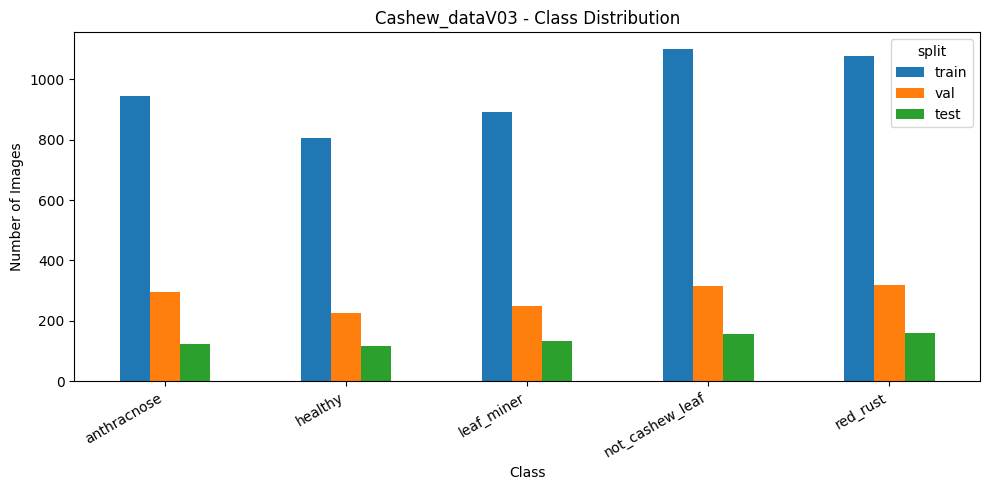

In [7]:

# ============================================================
# 07. DATASET DISTRIBUTION
# ============================================================

ax = stats_df[["train", "val", "test"]].plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Cashew_dataV03 - Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    AGGREGATE_DIR / "class_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


In [8]:

# ============================================================
# 08. FIXED FILE LISTS + TF.DATA
# ============================================================

CLASS_NAMES = EXPECTED_CLASSES
NUM_CLASSES = len(CLASS_NAMES)
AUTOTUNE = tf.data.AUTOTUNE


def split_arrays(split_name):
    df = (
        valid_df[valid_df["split"] == split_name]
        .copy()
        .reset_index(drop=True)
    )

    return (
        df["path"].to_numpy(),
        df["label"].to_numpy(dtype=np.int32),
        df
    )


train_paths, train_labels, train_meta = split_arrays("train")
val_paths, val_labels, val_meta = split_arrays("val")
test_paths, test_labels, test_meta = split_arrays("test")


def decode_image(path, label):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        method="bilinear"
    )

    return tf.cast(image, tf.float32), label


def make_dataset(paths, labels, seed, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        decode_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    ds = ds.prefetch(AUTOTUNE)

    return ds


print("Fixed split:")
print("Train :", len(train_paths))
print("Val   :", len(val_paths))
print("Test  :", len(test_paths))

print("\nClass mapping:")
for idx, class_name in enumerate(CLASS_NAMES):
    print(f"{idx}: {class_name}")


Fixed split:
Train : 4822
Val   : 1402
Test  : 687

Class mapping:
0: anthracnose
1: healthy
2: leaf_miner
3: not_cashew_leaf
4: red_rust



# Model Builder

Điểm quan trọng của bản rerun:

```python
x = backbone(x)
```

Không sử dụng:

```python
x = backbone(x, training=True)
```

Keras sẽ tự chuyển BatchNormalization/Dropout sang training mode khi `fit()` và inference mode khi Validation/Test.

Ngoài ra notebook chỉ dùng đúng hai function:

```python
build_data_augmentation(seed)
build_densenet121_model(seed)
```


In [9]:

# ============================================================
# 09. DATA AUGMENTATION + DENSENET121 MODEL BUILDER
# ============================================================

AUGMENTATION_CONFIG = {
    "horizontal_flip": True,
    "vertical_flip": False,
    "rotation_factor": 0.04,
    "zoom_factor": 0.05,
    "translation_factor": 0.03,
    "contrast_factor": 0.08,
    "brightness": False,
    "hue_shift": False,
}


def build_data_augmentation(seed):
    return keras.Sequential(
        [
            layers.RandomFlip(
                "horizontal",
                seed=seed + 1
            ),

            layers.RandomRotation(
                factor=0.04,
                seed=seed + 2
            ),

            layers.RandomZoom(
                height_factor=(-0.05, 0.05),
                width_factor=(-0.05, 0.05),
                seed=seed + 3
            ),

            layers.RandomTranslation(
                height_factor=0.03,
                width_factor=0.03,
                seed=seed + 4
            ),

            layers.RandomContrast(
                factor=0.08,
                seed=seed + 5
            ),
        ],
        name=f"data_augmentation_seed_{seed}"
    )


def build_densenet121_model(seed):

    set_global_seed(seed)

    augmentation = build_data_augmentation(seed)

    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="image"
    )

    # Augmentation chỉ hoạt động khi model ở training mode.
    x = augmentation(inputs)

    # Scratch training: normalize ảnh về [0,1].
    x = layers.Rescaling(
        1.0 / 255.0,
        name="rescale_0_1"
    )(x)

    backbone = tf.keras.applications.DenseNet121(
        include_top=False,
        weights=None,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    backbone.trainable = True

    # ========================================================
    # QUAN TRỌNG:
    # Không ép training=True.
    # ========================================================
    x = backbone(x)

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    x = layers.Dense(
        HEAD_UNITS,
        activation="relu",
        name="classifier_dense"
    )(x)

    x = layers.BatchNormalization(
        name="classifier_bn"
    )(x)

    x = layers.Dropout(
        HEAD_DROPOUT,
        seed=seed + 6,
        name="classifier_dropout"
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="predictions"
    )(x)

    return keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"DenseNet121_Scratch_seed_{seed}"
    )


print("Defined:")
print("- build_data_augmentation(seed)")
print("- build_densenet121_model(seed)")


Defined:
- build_data_augmentation(seed)
- build_densenet121_model(seed)


In [10]:

# ============================================================
# 10. MODEL BUILDER SANITY CHECK
# ============================================================

# Cell này giúp phát hiện lỗi function trước khi mất hàng giờ train.

tf.keras.backend.clear_session()
gc.collect()

sanity_seed = SEEDS[0]

with strategy.scope():
    sanity_model = build_densenet121_model(sanity_seed)

expected_output_shape = (None, NUM_CLASSES)

print("Model name        :", sanity_model.name)
print("Output shape      :", sanity_model.output_shape)
print("Total parameters  :", sanity_model.count_params())

assert sanity_model.output_shape == expected_output_shape
assert any(layer.name == "densenet121" for layer in sanity_model.layers)

print("\nSANITY CHECK PASSED.")
print("Training cell sẽ gọi đúng build_densenet121_model(seed).")

del sanity_model
tf.keras.backend.clear_session()
gc.collect()


Global seed set to: 42
Model name        : DenseNet121_Scratch_seed_42
Output shape      : (None, 5)
Total parameters  : 7566917

SANITY CHECK PASSED.
Training cell sẽ gọi đúng build_densenet121_model(seed).


0

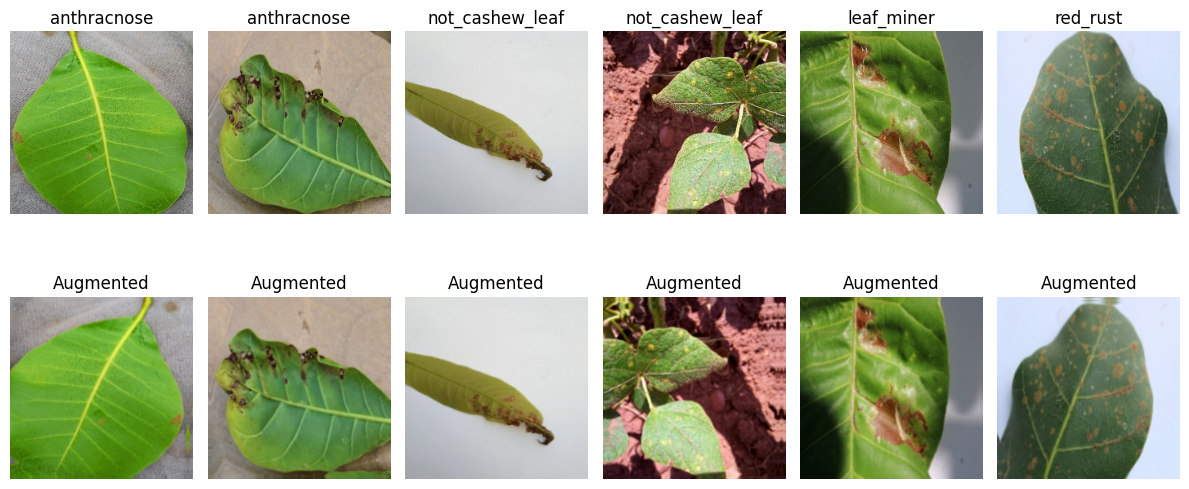

25329

In [11]:

# ============================================================
# 11. AUGMENTATION VISUAL CHECK
# ============================================================

preview_seed = SEEDS[0]

preview_ds = make_dataset(
    train_paths,
    train_labels,
    seed=preview_seed,
    training=True
)

preview_aug = build_data_augmentation(preview_seed)

for images, labels in preview_ds.take(1):

    n = min(6, int(images.shape[0]))

    plt.figure(figsize=(12, 6))

    for i in range(n):

        plt.subplot(2, 6, i + 1)
        plt.imshow(
            tf.cast(
                tf.clip_by_value(images[i], 0, 255),
                tf.uint8
            )
        )
        plt.title(CLASS_NAMES[int(labels[i])])
        plt.axis("off")

        aug_img = preview_aug(
            tf.expand_dims(images[i], 0),
            training=True
        )[0]

        plt.subplot(2, 6, i + 7)
        plt.imshow(
            tf.cast(
                tf.clip_by_value(aug_img, 0, 255),
                tf.uint8
            )
        )
        plt.title("Augmented")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

del preview_ds, preview_aug
gc.collect()


In [12]:

# ============================================================
# 12. SAVE EXPERIMENT CONFIG
# ============================================================

experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "created_at": datetime.now().isoformat(),

    "dataset": {
        "version": DATASET_VERSION,
        "path": str(DATASET_PATH),
        "classes": CLASS_NAMES,
        "train_images": len(train_paths),
        "val_images": len(val_paths),
        "test_images": len(test_paths),
        "total_images": len(valid_df),
        "test_set_locked": True,
    },

    "model": {
        "name": MODEL_NAME,
        "training_mode": TRAINING_MODE,
        "weights": PRETRAINED_WEIGHTS,
        "include_top": False,
        "input_size": [IMG_SIZE, IMG_SIZE, 3],
        "head_units": HEAD_UNITS,
        "head_dropout": HEAD_DROPOUT,
        "backbone_call": "x = backbone(x)",
        "forced_training_true": False,
    },

    "training": {
        "seeds": SEEDS,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "optimizer": "Adam",
        "initial_learning_rate": INITIAL_LR,
        "loss": "SparseCategoricalCrossentropy",
        "class_weight": None,
    },

    "augmentation": AUGMENTATION_CONFIG,

    "callbacks": {
        "checkpoint_monitor": "val_loss",
        "checkpoint_mode": "min",
        "checkpoint_type": "weights_only",
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "reduce_lr_factor": REDUCE_LR_FACTOR,
        "min_lr": MIN_LR,
    },

    "test_protocol": {
        "run_final_test": RUN_FINAL_TEST,
        "final_test_completed": False,
        "same_locked_test_for_all_seeds": True,
        "do_not_select_best_seed_on_test": True,
        "summary": "mean ± sample standard deviation (ddof=1)",
    },


"deployment_protocol": {
    "selection_source": "validation only",
    "selection_metric": "val_macro_f1",
    "tie_break": "lower val_loss",
    "test_used_for_selection": False,
},

"figure_protocol": {
    "comparison_layout": "panel",
    "training_curves": "2 rows x 5 seed columns",
    "confusion_matrices": "1 row x 5 seed columns",
},

"archive": {
    "full_archive": f"{EXPERIMENT_ID}_FULL.zip",
    "analysis_archive": f"{EXPERIMENT_ID}_ANALYSIS.zip",
    "google_drive_target_url": DRIVE_TARGET_URL,
    "google_drive_target_folder_id": DRIVE_TARGET_FOLDER_ID,
},

    "hardware": {
        "gpu_count": len(gpus),
        "strategy": strategy.__class__.__name__,
        "replicas": strategy.num_replicas_in_sync,
    },
}

config_path = OUT_DIR / "experiment_config.json"

config_path.write_text(
    json.dumps(
        experiment_config,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

print("Saved:", config_path)


drive_target_path = OUT_DIR / "drive_target.json"
drive_target_path.write_text(
    json.dumps(
        {
            "folder_url": DRIVE_TARGET_URL,
            "folder_id": DRIVE_TARGET_FOLDER_ID,
            "archive_to_upload": f"{EXPERIMENT_ID}_FULL.zip",
        },
        indent=2,
    ),
    encoding="utf-8",
)
print("Saved:", drive_target_path)


Saved: /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/experiment_config.json
Saved: /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/drive_target.json



# Train 5 Seeds

Cell tiếp theo chạy lần lượt:

```text
42 → 123 → 2026 → 3407 → 7777
```

Mỗi seed:
- tạo model mới hoàn toàn;
- train cùng một split;
- lưu `best.weights.h5` theo `val_loss`;
- lưu `history.csv`;
- lưu learning curves;
- sau train, **reload đúng best weights**;
- đánh giá Validation và lưu Macro-F1 / Balanced Accuracy / confusion matrix.

Test **không được đọc** trong cell này.


In [13]:

# ============================================================
# 13. TRAIN ALL 5 SEEDS
# ============================================================

training_rows = []
validation_rows = []

for run_index, seed in enumerate(SEEDS, start=1):

    print("\n" + "=" * 80)
    print(f"RUN {run_index}/{len(SEEDS)} - SEED {seed}")
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()
    set_global_seed(seed)

    # --------------------------------------------------------
    # Folders
    # --------------------------------------------------------

    seed_dir = OUT_DIR / f"seed_{seed}"

    checkpoint_dir = seed_dir / "checkpoints"
    log_dir = seed_dir / "logs"
    figure_dir = seed_dir / "figures"
    validation_dir = seed_dir / "validation"

    for folder in [
        checkpoint_dir,
        log_dir,
        figure_dir,
        validation_dir,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    best_weights_path = (
        checkpoint_dir /
        f"DENSENET121_SCRATCH_seed_{seed}_best.weights.h5"
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    train_ds = make_dataset(
        train_paths,
        train_labels,
        seed=seed,
        training=True
    )

    val_ds = make_dataset(
        val_paths,
        val_labels,
        seed=seed,
        training=False
    )

    # --------------------------------------------------------
    # Build + compile
    # --------------------------------------------------------

    with strategy.scope():

        # CHỈ dùng function này.
        model = build_densenet121_model(seed)

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=INITIAL_LR
            ),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"],
        )

    # --------------------------------------------------------
    # Model summary
    # --------------------------------------------------------

    summary_lines = []

    model.summary(
        print_fn=lambda line: summary_lines.append(line)
    )

    (
        seed_dir /
        "model_summary.txt"
    ).write_text(
        "\n".join(summary_lines),
        encoding="utf-8"
    )

    total_params = int(model.count_params())

    trainable_params = int(
        np.sum([
            np.prod(v.shape)
            for v in model.trainable_weights
        ])
    )

    non_trainable_params = int(
        total_params - trainable_params
    )

    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    callbacks = [

        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(best_weights_path),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=MIN_LR,
            verbose=1,
        ),

        tf.keras.callbacks.CSVLogger(
            str(log_dir / "training_log.csv")
        ),
    ]

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    training_time_seconds = time.time() - start_time

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history_df = pd.DataFrame(history.history)

    history_df.insert(
        0,
        "epoch",
        np.arange(1, len(history_df) + 1)
    )

    history_df.to_csv(
        log_dir / "history.csv",
        index=False
    )

    actual_epochs = len(history_df)

    best_epoch = int(
        np.argmin(history.history["val_loss"])
    ) + 1

    best_val_loss_history = float(
        np.min(history.history["val_loss"])
    )

    best_val_accuracy_history = float(
        history.history["val_accuracy"][best_epoch - 1]
    )

    # --------------------------------------------------------
    # Curves
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["accuracy"],
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_accuracy"],
        label="Validation"
    )

    plt.axvline(
        best_epoch,
        linestyle="--",
        label=f"Best epoch = {best_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"DenseNet121 Scratch - Seed {seed} - Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        figure_dir / "accuracy_curve.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["loss"],
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label="Validation"
    )

    plt.axvline(
        best_epoch,
        linestyle="--",
        label=f"Best epoch = {best_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"DenseNet121 Scratch - Seed {seed} - Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        figure_dir / "loss_curve.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    # --------------------------------------------------------
    # IMPORTANT:
    # Reload exactly the checkpoint chosen by minimum val_loss.
    # --------------------------------------------------------

    model.load_weights(best_weights_path)

    # --------------------------------------------------------
    # Validation evaluation
    # --------------------------------------------------------

    val_loss, val_accuracy = model.evaluate(
        val_ds,
        verbose=0
    )

    y_val_true = []
    y_val_prob = []

    for images, labels in val_ds:

        probs = model.predict(
            images,
            verbose=0
        )

        y_val_prob.append(probs)
        y_val_true.append(labels.numpy())

    y_val_true = np.concatenate(y_val_true)
    y_val_prob = np.concatenate(y_val_prob)
    y_val_pred = np.argmax(y_val_prob, axis=1)
    y_val_conf = np.max(y_val_prob, axis=1)

    val_metrics = {
        "seed": seed,
        "val_loss": float(val_loss),
        "val_accuracy": float(
            accuracy_score(y_val_true, y_val_pred)
        ),
        "val_macro_precision": float(
            precision_score(
                y_val_true,
                y_val_pred,
                average="macro",
                zero_division=0
            )
        ),
        "val_macro_recall": float(
            recall_score(
                y_val_true,
                y_val_pred,
                average="macro",
                zero_division=0
            )
        ),
        "val_macro_f1": float(
            f1_score(
                y_val_true,
                y_val_pred,
                average="macro",
                zero_division=0
            )
        ),
        "val_balanced_accuracy": float(
            balanced_accuracy_score(
                y_val_true,
                y_val_pred
            )
        ),
    }

    validation_rows.append(val_metrics)

    # --------------------------------------------------------
    # Validation classification report
    # --------------------------------------------------------

    val_report_df = pd.DataFrame(
        classification_report(
            y_val_true,
            y_val_pred,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()

    val_report_df.to_csv(
        validation_dir /
        "classification_report.csv"
    )

    # --------------------------------------------------------
    # Validation confusion matrix
    # --------------------------------------------------------

    val_cm = confusion_matrix(
        y_val_true,
        y_val_pred
    )

    val_cm_norm = confusion_matrix(
        y_val_true,
        y_val_pred,
        normalize="true"
    )

    pd.DataFrame(
        val_cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    ).to_csv(
        validation_dir /
        "confusion_matrix.csv"
    )

    pd.DataFrame(
        val_cm_norm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    ).to_csv(
        validation_dir /
        "confusion_matrix_normalized.csv"
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    ConfusionMatrixDisplay(
        confusion_matrix=val_cm,
        display_labels=CLASS_NAMES
    ).plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    plt.title(
        f"Validation Confusion Matrix - Seed {seed}"
    )

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        validation_dir /
        "confusion_matrix.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    val_predictions_df = pd.DataFrame({
        "filename": val_meta["path"],
        "true_label": [
            CLASS_NAMES[int(i)]
            for i in y_val_true
        ],
        "predicted_label": [
            CLASS_NAMES[int(i)]
            for i in y_val_pred
        ],
        "confidence": y_val_conf,
        "correct": y_val_true == y_val_pred,
    })

    val_predictions_df.to_csv(
        validation_dir /
        "predictions.csv",
        index=False
    )

    # --------------------------------------------------------
    # Training summary
    # --------------------------------------------------------

    row = {
        "seed": seed,
        "actual_epochs": actual_epochs,
        "best_epoch": best_epoch,
        "best_val_loss_history": best_val_loss_history,
        "best_val_accuracy_history": best_val_accuracy_history,
        "checkpoint_val_loss": float(val_loss),
        "checkpoint_val_accuracy": float(val_metrics["val_accuracy"]),
        "checkpoint_val_macro_f1": float(val_metrics["val_macro_f1"]),
        "checkpoint_val_balanced_accuracy": float(
            val_metrics["val_balanced_accuracy"]
        ),
        "training_time_seconds": float(training_time_seconds),
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
        "non_trainable_parameters": non_trainable_params,
        "best_weights_path": str(best_weights_path),
        "best_weights_size_mb": float(
            best_weights_path.stat().st_size /
            (1024 ** 2)
        ),
    }

    training_rows.append(row)

    (
        seed_dir /
        "training_summary.json"
    ).write_text(
        json.dumps(
            row,
            indent=2
        ),
        encoding="utf-8"
    )

    print("\nSeed summary:")
    print(json.dumps(row, indent=2))

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model
    del train_ds
    del val_ds
    del history

    tf.keras.backend.clear_session()
    gc.collect()


training_summary_df = pd.DataFrame(training_rows)
validation_results_df = pd.DataFrame(validation_rows)

training_summary_df.to_csv(
    AGGREGATE_DIR /
    "training_summary_5seeds.csv",
    index=False
)

validation_results_df.to_csv(
    AGGREGATE_DIR /
    "validation_results_5seeds.csv",
    index=False
)

print("\nTraining summary:")
display(training_summary_df)

print("\nValidation metrics:")
display(validation_results_df)



RUN 1/5 - SEED 42
Global seed set to: 42
Global seed set to: 42


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

2026-09-22 03:32:44.212652: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-22 03:32:51.013337: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Seed summary:
{
  "seed": 42,
  "actual_epochs": 34,
  "best_epoch": 26,
  "best_val_loss_history": 0.37278541922569275,
  "best_val_accuracy_history": 0.8823109865188599,
  "checkpoint_val_loss": 0.36645743250846863,
  "checkpoint_val_accuracy": 0.884450784593438,
  "checkpoint_val_macro_f1": 0.8796975612062232,
  "checkpoint_val_balanced_accuracy": 0.8836503246183748,
  "training_time_seconds": 2459.6113481521606,
  "total_parameters": 7566917,
  "trainable_parameters": 7482245,
  "non_trainable_parameters": 84672,
  "best_weights_path": "/kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/seed_42/checkpoints/DENSENET121_SCRATCH_seed_42_best.weights.h5",
  "best_weights_size_mb": 87.29659271240234
}

RUN 2/5 - SEED 123
Global seed set to: 123
Global seed set to: 123


Epoch 1/50
INFO:tensorflow:Collective all_reduce tensors: 368 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.5166 - loss: 1.3871
Epoch 1: val_loss improved from None to 2.28610, saving model to /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/seed_123/checkpoints/DENSENET121_SCRATCH_seed_123_best.weights.h5

Epoch 1: finished saving model to /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/seed_123/checkpoints/DENSENET121_SCRATCH_seed_123_best.weights.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 160s 539ms/step - accuracy: 0.5705 - loss: 1.1882 - val_accuracy: 0.1562 - val_loss: 2.2861 - learning_rate: 0.0010
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.6814 - loss: 0.8813
Epoch 2: val_loss did not improve from 2.28610
151/151 ━━━━━━━━━━━━━━━━━━━━ 70s 463ms/step - accuracy: 0.6869 - loss: 0.8643 - val_accuracy: 0.2710 - val_loss: 4.3297 - learning_rate:

...

2026-09-22 06:12:13.886155: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-22 06:12:23.517952: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Seed summary:
{
  "seed": 7777,
  "actual_epochs": 33,
  "best_epoch": 25,
  "best_val_loss_history": 0.26334503293037415,
  "best_val_accuracy_history": 0.9308131337165833,
  "checkpoint_val_loss": 0.26497140526771545,
  "checkpoint_val_accuracy": 0.9300998573466477,
  "checkpoint_val_macro_f1": 0.9280876095823503,
  "checkpoint_val_balanced_accuracy": 0.9280130067042294,
  "training_time_seconds": 2404.19149184227,
  "total_parameters": 7566917,
  "trainable_parameters": 7482245,
  "non_trainable_parameters": 84672,
  "best_weights_path": "/kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/seed_7777/checkpoints/DENSENET121_SCRATCH_seed_7777_best.weights.h5",
  "best_weights_size_mb": 87.29659271240234
}

Training summary:


,seed,actual_epochs,best_epoch,best_val_loss_history,best_val_accuracy_history,checkpoint_val_loss,checkpoint_val_accuracy,checkpoint_val_macro_f1,checkpoint_val_balanced_accuracy,training_time_seconds,total_parameters,trainable_parameters,non_trainable_parameters,best_weights_path,best_weights_size_mb
0,42,34,26,0.372785,0.882311,0.366457,0.884451,0.879698,0.883650,2459.611348,7566917,7482245,84672,/kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS...,87.296593
1,123,31,23,0.346094,0.886591,0.347699,0.885877,0.881002,0.882882,2253.060852,7566917,7482245,84672,/kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS...,87.296593
2,2026,38,30,0.335307,0.898716,0.335397,0.898716,0.896081,0.894906,2734.057636,7566917,7482245,84672,/kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS...,87.296593
3,3407,27,19,0.347803,0.892297,0.345820,0.894437,0.891766,0.891374,1977.328847,7566917,7482245,84672,/kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS...,87.296593
4,7777,33,25,0.263345,0.930813,0.264971,0.930100,0.928088,0.928013,2404.191492,7566917,7482245,84672,/kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS...,87.296593



Validation metrics:


,seed,val_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_balanced_accuracy
0,42,0.366457,0.884451,0.884538,0.883650,0.879698,0.883650
1,123,0.347699,0.885877,0.884575,0.882882,0.881002,0.882882
2,2026,0.335397,0.898716,0.898538,0.894906,0.896081,0.894906
3,3407,0.345820,0.894437,0.895221,0.891374,0.891766,0.891374
4,7777,0.264971,0.930100,0.929016,0.928013,0.928088,0.928013


In [14]:

# ============================================================
# 14. VALIDATION MEAN ± STD
# ============================================================

validation_metrics_to_summarize = [
    "val_accuracy",
    "val_macro_precision",
    "val_macro_recall",
    "val_macro_f1",
    "val_balanced_accuracy",
]

validation_summary_rows = []

for metric in validation_metrics_to_summarize:

    values = validation_results_df[metric]

    validation_summary_rows.append({
        "metric": metric,
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
        "report": (
            f"{values.mean()*100:.2f} ± "
            f"{values.std(ddof=1)*100:.2f}%"
        ),
    })

validation_mean_std_df = pd.DataFrame(
    validation_summary_rows
)

display(validation_mean_std_df)

validation_mean_std_df.to_csv(
    AGGREGATE_DIR /
    "validation_mean_std_summary.csv",
    index=False
)

print("\nBest epoch across seeds:")
print(
    f"{training_summary_df['best_epoch'].mean():.2f} ± "
    f"{training_summary_df['best_epoch'].std(ddof=1):.2f}"
)


,metric,mean,std,report
0,val_accuracy,0.898716,0.018517,89.87 ± 1.85%
1,val_macro_precision,0.898378,0.018240,89.84 ± 1.82%
2,val_macro_recall,0.896165,0.018519,89.62 ± 1.85%
3,val_macro_f1,0.895327,0.019596,89.53 ± 1.96%
4,val_balanced_accuracy,0.896165,0.018519,89.62 ± 1.85%



Best epoch across seeds:
24.60 ± 4.04


Created: /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/figures/panels/training_curves_5seeds_panel.png
Created: /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/figures/panels/validation_confusion_matrices_5seeds_panel.png


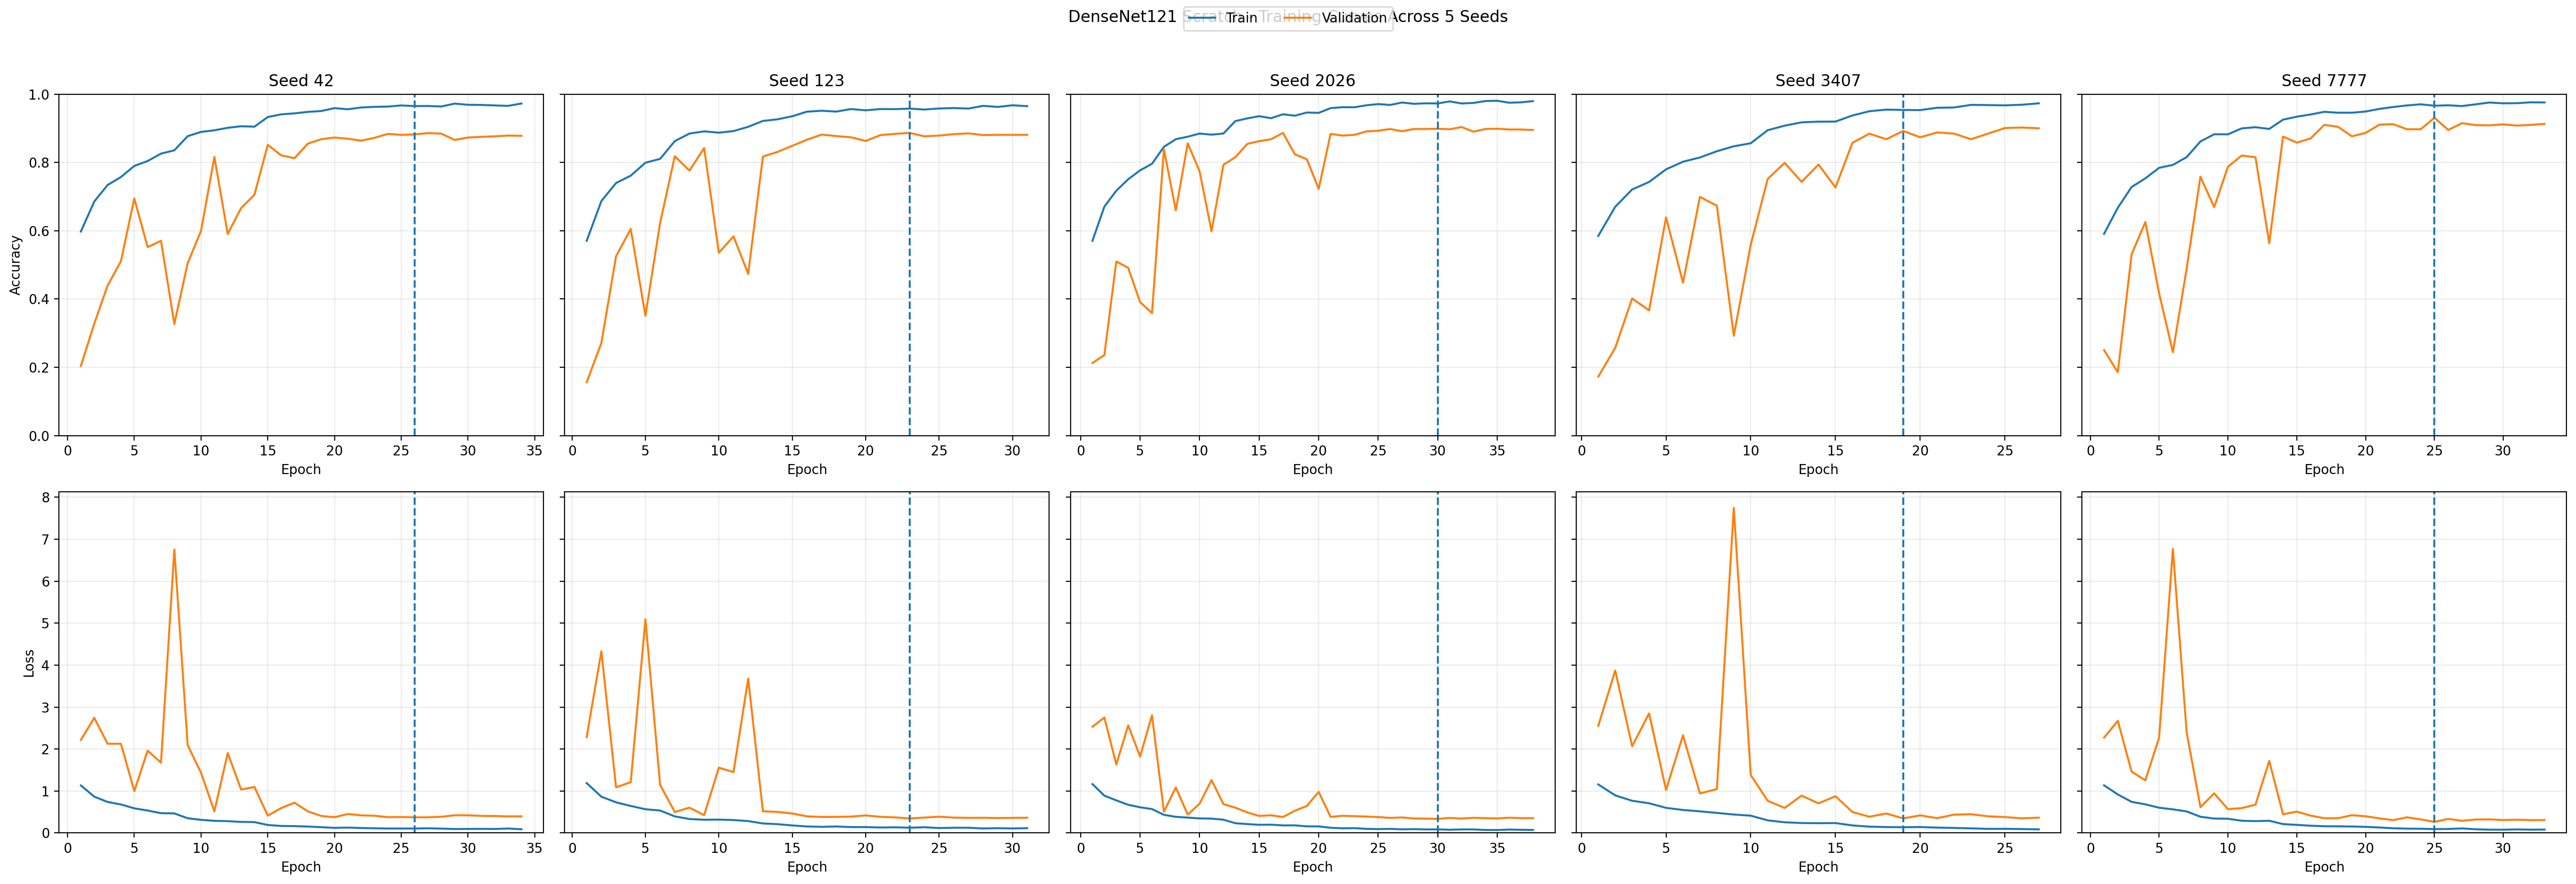

In [15]:

# ============================================================
# 14B. PAPER-STYLE 5-SEED VALIDATION PANELS
# ============================================================

# ------------------------------------------------------------
# A. Training curves: 2 rows x 5 seed columns
#    Row 1 = Accuracy, Row 2 = Loss
# ------------------------------------------------------------

histories = {}
for seed in SEEDS:
    history_path = OUT_DIR / f"seed_{seed}" / "logs" / "history.csv"
    histories[seed] = pd.read_csv(history_path)

fig, axes = plt.subplots(
    2,
    len(SEEDS),
    figsize=(27, 9),
    sharey="row"
)

all_losses = []
for seed in SEEDS:
    all_losses.extend(histories[seed]["loss"].tolist())
    all_losses.extend(histories[seed]["val_loss"].tolist())

loss_upper = max(all_losses) * 1.05

for col, seed in enumerate(SEEDS):
    hist = histories[seed]
    best_epoch = int(hist.loc[hist["val_loss"].idxmin(), "epoch"])

    axes[0, col].plot(hist["epoch"], hist["accuracy"], label="Train")
    axes[0, col].plot(hist["epoch"], hist["val_accuracy"], label="Validation")
    axes[0, col].axvline(best_epoch, linestyle="--")
    axes[0, col].set_title(f"Seed {seed}")
    axes[0, col].set_xlabel("Epoch")
    axes[0, col].set_ylim(0, 1)
    axes[0, col].grid(alpha=0.25)

    axes[1, col].plot(hist["epoch"], hist["loss"], label="Train")
    axes[1, col].plot(hist["epoch"], hist["val_loss"], label="Validation")
    axes[1, col].axvline(best_epoch, linestyle="--")
    axes[1, col].set_xlabel("Epoch")
    axes[1, col].set_ylim(0, loss_upper)
    axes[1, col].grid(alpha=0.25)

axes[0, 0].set_ylabel("Accuracy")
axes[1, 0].set_ylabel("Loss")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle(
    "DenseNet121 Scratch - Training Curves Across 5 Seeds",
    y=1.02
)
fig.tight_layout()

training_panel_path = PANEL_DIR / "training_curves_5seeds_panel.png"
fig.savefig(training_panel_path, dpi=200, bbox_inches="tight")
plt.close(fig)

# ------------------------------------------------------------
# B. Normalized Validation confusion matrices: 1 x 5
# ------------------------------------------------------------

fig, axes = plt.subplots(1, len(SEEDS), figsize=(28, 5.5))

for col, seed in enumerate(SEEDS):
    cm_path = (
        OUT_DIR / f"seed_{seed}" / "validation" /
        "confusion_matrix_normalized.csv"
    )
    cm = pd.read_csv(cm_path, index_col=0).to_numpy()
    axes[col].imshow(cm, vmin=0, vmax=1, aspect="auto")
    axes[col].set_title(f"Seed {seed}")
    axes[col].set_xticks(range(NUM_CLASSES))
    axes[col].set_yticks(range(NUM_CLASSES))
    axes[col].set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    if col == 0:
        axes[col].set_yticklabels(CLASS_NAMES)
        axes[col].set_ylabel("True label")
    else:
        axes[col].set_yticklabels([])
    axes[col].set_xlabel("Predicted label")

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            axes[col].text(
                j, i, f"{cm[i, j]:.2f}",
                ha="center", va="center", fontsize=8
            )

fig.suptitle(
    "DenseNet121 Scratch - Validation Normalized Confusion Matrices Across 5 Seeds",
    y=1.03
)
fig.tight_layout()
validation_panel_path = PANEL_DIR / "validation_confusion_matrices_5seeds_panel.png"
fig.savefig(validation_panel_path, dpi=200, bbox_inches="tight")
plt.close(fig)

print("Created:", training_panel_path)
print("Created:", validation_panel_path)
display(Image.open(training_panel_path))



# FINAL TEST GATE

**Dừng ở đây nếu bạn chưa muốn mở Test Set.**

Sau khi 5 seeds đã train xong và bạn xác nhận cấu hình không thay đổi nữa:

1. quay lại Cell `03. CONFIGURATION`;
2. đổi:

```python
RUN_FINAL_TEST = True
```

3. chạy lại Cell 03;
4. **không chạy lại Cell Train**;
5. chạy từ cell `15. FINAL TEST` trở xuống.

Final Test sẽ build lại đúng architecture cho từng seed, load `best.weights.h5`, rồi đánh giá cùng một Test Set đã khóa.


In [16]:

# ============================================================
# 15. FINAL TEST - 5 SEEDS
# ============================================================

test_result_rows = []

if not RUN_FINAL_TEST:

    print(
        "FINAL TEST IS LOCKED.\n"
        "RUN_FINAL_TEST = False\n"
        "Không đánh giá Test trong lần chạy này."
    )

else:

    test_ds = make_dataset(
        test_paths,
        test_labels,
        seed=SEEDS[0],
        training=False
    )

    for run_index, seed in enumerate(SEEDS, start=1):

        print("\n" + "=" * 80)
        print(
            f"FINAL TEST {run_index}/{len(SEEDS)} - SEED {seed}"
        )
        print("=" * 80)

        tf.keras.backend.clear_session()
        gc.collect()
        set_global_seed(seed)

        seed_dir = OUT_DIR / f"seed_{seed}"

        best_weights_path = (
            seed_dir /
            "checkpoints" /
            f"DENSENET121_SCRATCH_seed_{seed}_best.weights.h5"
        )

        if not best_weights_path.exists():
            raise FileNotFoundError(
                f"Missing checkpoint: {best_weights_path}"
            )

        metric_dir = seed_dir / "test_metrics"
        figure_dir = seed_dir / "test_figures"
        prediction_dir = seed_dir / "test_predictions"
        error_dir = prediction_dir / "error_cases"

        for folder in [
            metric_dir,
            figure_dir,
            prediction_dir,
            error_dir,
        ]:
            folder.mkdir(
                parents=True,
                exist_ok=True
            )

        # ----------------------------------------------------
        # Rebuild exact architecture and load best weights
        # ----------------------------------------------------

        with strategy.scope():

            model = build_densenet121_model(seed)

            # Load weights BEFORE compile so Final Test does not
            # attempt to restore stale optimizer variables.
            model.load_weights(
                best_weights_path
            )

            model.compile(
                optimizer=tf.keras.optimizers.Adam(
                    learning_rate=INITIAL_LR
                ),
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=["accuracy"],
            )

        # ----------------------------------------------------
        # Evaluate
        # ----------------------------------------------------

        test_loss, test_accuracy_keras = model.evaluate(
            test_ds,
            verbose=0
        )

        # Warm-up bằng nguyên batch đầu tiên.
        # Không dùng batch=1 khi MirroredStrategy có nhiều GPU.
        _ = model.predict(
            test_ds.take(1),
            verbose=0
        )

        prediction_start = time.perf_counter()

        # Predict toàn bộ Test Dataset trong một call để giảm overhead
        # và cho phép MirroredStrategy tự phân phối batch ổn định.
        y_prob = model.predict(
            test_ds,
            verbose=0
        )

        prediction_time = (
            time.perf_counter() -
            prediction_start
        )

        # Test dataset không shuffle nên thứ tự prediction
        # trùng với test_labels.
        y_true = np.asarray(
            test_labels,
            dtype=np.int32
        )

        y_pred = np.argmax(
            y_prob,
            axis=1
        )

        confidences = np.max(
            y_prob,
            axis=1
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        macro_precision = precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        balanced_acc = balanced_accuracy_score(
            y_true,
            y_pred
        )

        weighted_precision = precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        weighted_recall = recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        inference_ms = (
            prediction_time /
            len(y_true)
        ) * 1000.0

        fps = (
            len(y_true) /
            prediction_time
        )

        # ----------------------------------------------------
        # Reports
        # ----------------------------------------------------

        report_df = pd.DataFrame(
            classification_report(
                y_true,
                y_pred,
                target_names=CLASS_NAMES,
                output_dict=True,
                zero_division=0,
            )
        ).transpose()

        report_df.to_csv(
            metric_dir /
            "classification_report.csv"
        )

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        cm_norm = confusion_matrix(
            y_true,
            y_pred,
            normalize="true"
        )

        pd.DataFrame(
            cm,
            index=CLASS_NAMES,
            columns=CLASS_NAMES
        ).to_csv(
            metric_dir /
            "confusion_matrix.csv"
        )

        pd.DataFrame(
            cm_norm,
            index=CLASS_NAMES,
            columns=CLASS_NAMES
        ).to_csv(
            metric_dir /
            "confusion_matrix_normalized.csv"
        )

        # ----------------------------------------------------
        # Confusion matrix figures
        # ----------------------------------------------------

        fig, ax = plt.subplots(figsize=(8, 7))

        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES
        ).plot(
            ax=ax,
            cmap="Blues",
            values_format="d",
            colorbar=False
        )

        plt.title(
            f"Test Confusion Matrix - Seed {seed}"
        )

        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()

        plt.savefig(
            figure_dir /
            "confusion_matrix.png",
            dpi=200,
            bbox_inches="tight"
        )

        plt.close()

        fig, ax = plt.subplots(figsize=(8, 7))

        ConfusionMatrixDisplay(
            confusion_matrix=cm_norm,
            display_labels=CLASS_NAMES
        ).plot(
            ax=ax,
            cmap="Blues",
            values_format=".2f",
            colorbar=False
        )

        plt.title(
            f"Normalized Test Confusion Matrix - Seed {seed}"
        )

        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()

        plt.savefig(
            figure_dir /
            "confusion_matrix_normalized.png",
            dpi=200,
            bbox_inches="tight"
        )

        plt.close()

        # ----------------------------------------------------
        # Prediction CSV
        # ----------------------------------------------------

        predictions_df = pd.DataFrame({
            "filename": test_meta["path"],
            "true_label": [
                CLASS_NAMES[int(i)]
                for i in y_true
            ],
            "predicted_label": [
                CLASS_NAMES[int(i)]
                for i in y_pred
            ],
            "confidence": confidences,
            "correct": y_true == y_pred,
        })

        predictions_df.to_csv(
            prediction_dir /
            "predictions.csv",
            index=False
        )

        wrong_df = (
            predictions_df[
                ~predictions_df["correct"]
            ]
            .sort_values(
                "confidence",
                ascending=False
            )
        )

        wrong_df.head(20).to_csv(
            error_dir /
            "highest_confidence_wrong.csv",
            index=False
        )

        correct_low_conf = (
            predictions_df[
                predictions_df["correct"]
            ]
            .sort_values(
                "confidence",
                ascending=True
            )
        )

        correct_low_conf.head(20).to_csv(
            error_dir /
            "lowest_confidence_correct.csv",
            index=False
        )

        # ----------------------------------------------------
        # Seed metrics
        # ----------------------------------------------------

        seed_metrics = {
            "seed": seed,
            "test_loss": float(test_loss),
            "accuracy": float(accuracy),
            "macro_precision": float(macro_precision),
            "macro_recall": float(macro_recall),
            "macro_f1": float(macro_f1),
            "balanced_accuracy": float(balanced_acc),
            "weighted_precision": float(weighted_precision),
            "weighted_recall": float(weighted_recall),
            "weighted_f1": float(weighted_f1),
            "weights_size_mb": float(
                best_weights_path.stat().st_size /
                (1024 ** 2)
            ),
            "inference_time_ms_per_image": float(inference_ms),
            "fps": float(fps),
        }

        (
            metric_dir /
            "metrics.json"
        ).write_text(
            json.dumps(
                seed_metrics,
                indent=2
            ),
            encoding="utf-8"
        )

        test_result_rows.append(
            seed_metrics
        )

        print(json.dumps(seed_metrics, indent=2))

        del model
        tf.keras.backend.clear_session()
        gc.collect()


    test_results_df = pd.DataFrame(
        test_result_rows
    )

    test_results_df.to_csv(
        AGGREGATE_DIR /
        "aggregate_test_results.csv",
        index=False
    )

    display(test_results_df)



FINAL TEST 1/5 - SEED 42
Global seed set to: 42
Global seed set to: 42
{
  "seed": 42,
  "test_loss": 0.24426843225955963,
  "accuracy": 0.9213973799126638,
  "macro_precision": 0.9163997088683293,
  "macro_recall": 0.9165513965952051,
  "macro_f1": 0.9158656130347669,
  "balanced_accuracy": 0.9165513965952051,
  "weighted_precision": 0.9220368772744011,
  "weighted_recall": 0.9213973799126638,
  "weighted_f1": 0.9211190334068634,
  "weights_size_mb": 87.29659271240234,
  "inference_time_ms_per_image": 13.113665133914102,
  "fps": 76.25633183310705
}

FINAL TEST 2/5 - SEED 123
Global seed set to: 123
Global seed set to: 123
{
  "seed": 123,
  "test_loss": 0.24380630254745483,
  "accuracy": 0.9228529839883551,
  "macro_precision": 0.9230990519148154,
  "macro_recall": 0.9192657106935144,
  "macro_f1": 0.9196672052298756,
  "balanced_accuracy": 0.9192657106935144,
  "weighted_precision": 0.9281967587823156,
  "weighted_recall": 0.9228529839883551,
  "weighted_f1": 0.9240932160258237,
  

,seed,test_loss,accuracy,macro_precision,macro_recall,macro_f1,balanced_accuracy,weighted_precision,weighted_recall,weighted_f1,weights_size_mb,inference_time_ms_per_image,fps
0,42,0.244268,0.921397,0.916400,0.916551,0.915866,0.916551,0.922037,0.921397,0.921119,87.296593,13.113665,76.256332
1,123,0.243806,0.922853,0.923099,0.919266,0.919667,0.919266,0.928197,0.922853,0.924093,87.296593,13.075145,76.480987
2,2026,0.262569,0.914119,0.911422,0.910647,0.910114,0.910647,0.918747,0.914119,0.915566,87.296593,13.297126,75.204219
3,3407,0.283715,0.905386,0.905762,0.901733,0.901774,0.901733,0.912766,0.905386,0.907205,87.296593,13.168588,75.938287
4,7777,0.260709,0.927220,0.923809,0.921804,0.921264,0.921804,0.927628,0.927220,0.926004,87.296593,13.327794,75.031173


In [17]:

# ============================================================
# 16. TEST MEAN ± STD + THESIS TABLE
# ============================================================

if not RUN_FINAL_TEST:

    print(
        "Skipped: Final Test chưa chạy."
    )

else:

    summary_metrics = [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "balanced_accuracy",
        "weighted_f1",
        "inference_time_ms_per_image",
        "fps",
    ]

    summary_rows = []

    for metric in summary_metrics:

        values = test_results_df[metric]

        summary_rows.append({
            "metric": metric,
            "mean": float(values.mean()),
            "std": float(values.std(ddof=1)),
            "report": (
                f"{values.mean():.6f} ± "
                f"{values.std(ddof=1):.6f}"
            ),
        })

    mean_std_df = pd.DataFrame(
        summary_rows
    )

    display(mean_std_df)

    mean_std_df.to_csv(
        AGGREGATE_DIR /
        "test_mean_std_summary.csv",
        index=False
    )

    thesis_metrics = [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "balanced_accuracy",
        "weighted_f1",
    ]

    thesis_rows = []

    for metric in thesis_metrics:

        values = (
            test_results_df[metric]
            * 100
        )

        thesis_rows.append({
            "Metric": metric,
            "Mean (%)": float(values.mean()),
            "Std (%)": float(values.std(ddof=1)),
            "Report": (
                f"{values.mean():.2f} ± "
                f"{values.std(ddof=1):.2f}%"
            ),
        })

    thesis_summary_df = pd.DataFrame(
        thesis_rows
    )

    print("\nThesis-ready table:")
    display(thesis_summary_df)

    thesis_summary_df.to_csv(
        AGGREGATE_DIR /
        "thesis_test_mean_std_summary.csv",
        index=False
    )

    aggregate_metrics = {
        "experiment_id": EXPERIMENT_ID,
        "model": MODEL_NAME,
        "training_mode": TRAINING_MODE,
        "dataset": DATASET_VERSION,
        "seeds": SEEDS,
        "num_seeds": len(SEEDS),
        "std_definition": "sample standard deviation (ddof=1)",
        "test_set_locked": True,
        "per_seed_results": test_result_rows,
        "summary": {
            row["metric"]: {
                "mean": float(row["mean"]),
                "std": float(row["std"]),
            }
            for row in summary_rows
        },
    }

    (
        AGGREGATE_DIR /
        "aggregate_test_metrics.json"
    ).write_text(
        json.dumps(
            aggregate_metrics,
            indent=2
        ),
        encoding="utf-8"
    )


,metric,mean,std,report
0,accuracy,0.918195,0.008574,0.918195 ± 0.008574
1,macro_precision,0.916098,0.007702,0.916098 ± 0.007702
2,macro_recall,0.914000,0.008014,0.914000 ± 0.008014
3,macro_f1,0.913737,0.007947,0.913737 ± 0.007947
4,balanced_accuracy,0.914000,0.008014,0.914000 ± 0.008014
5,weighted_f1,0.918797,0.007586,0.918797 ± 0.007586
6,inference_time_ms_per_image,13.196464,0.111503,13.196464 ± 0.111503
7,fps,75.782200,0.639447,75.782200 ± 0.639447



Thesis-ready table:


,Metric,Mean (%),Std (%),Report
0,accuracy,91.819505,0.857448,91.82 ± 0.86%
1,macro_precision,91.609816,0.770170,91.61 ± 0.77%
2,macro_recall,91.400035,0.801355,91.40 ± 0.80%
3,macro_f1,91.373683,0.794683,91.37 ± 0.79%
4,balanced_accuracy,91.400035,0.801355,91.40 ± 0.80%
5,weighted_f1,91.879734,0.758617,91.88 ± 0.76%


In [18]:

# ============================================================
# 17. PER-CLASS MEAN ± STD ACROSS 5 SEEDS
# ============================================================

if not RUN_FINAL_TEST:

    print(
        "Skipped: Final Test chưa chạy."
    )

else:

    per_class_rows = []

    for class_name in CLASS_NAMES:

        precision_values = []
        recall_values = []
        f1_values = []

        for seed in SEEDS:

            report_path = (
                OUT_DIR /
                f"seed_{seed}" /
                "test_metrics" /
                "classification_report.csv"
            )

            report_df = pd.read_csv(
                report_path,
                index_col=0
            )

            precision_values.append(
                float(
                    report_df.loc[
                        class_name,
                        "precision"
                    ]
                )
            )

            recall_values.append(
                float(
                    report_df.loc[
                        class_name,
                        "recall"
                    ]
                )
            )

            f1_values.append(
                float(
                    report_df.loc[
                        class_name,
                        "f1-score"
                    ]
                )
            )

        per_class_rows.append({
            "class": class_name,
            "precision_mean": np.mean(precision_values),
            "precision_std": np.std(precision_values, ddof=1),
            "recall_mean": np.mean(recall_values),
            "recall_std": np.std(recall_values, ddof=1),
            "f1_mean": np.mean(f1_values),
            "f1_std": np.std(f1_values, ddof=1),
            "f1_report": (
                f"{np.mean(f1_values)*100:.2f} ± "
                f"{np.std(f1_values, ddof=1)*100:.2f}%"
            ),
        })

    per_class_summary_df = pd.DataFrame(
        per_class_rows
    )

    display(per_class_summary_df)

    per_class_summary_df.to_csv(
        AGGREGATE_DIR /
        "per_class_test_mean_std.csv",
        index=False
    )


,class,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,f1_report
0,anthracnose,0.801152,0.067023,0.831148,0.046584,0.813045,0.020040,81.30 ± 2.00%
1,healthy,0.900930,0.024546,0.933898,0.021936,0.916843,0.015146,91.68 ± 1.51%
2,leaf_miner,0.943340,0.046674,0.886364,0.028346,0.912878,0.013713,91.29 ± 1.37%
3,not_cashew_leaf,0.983909,0.010304,0.937580,0.017091,0.960166,0.013514,96.02 ± 1.35%
4,red_rust,0.951161,0.013615,0.981013,0.010007,0.965752,0.004217,96.58 ± 0.42%


Created: /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/figures/panels/test_confusion_matrices_5seeds_panel.png
Created: /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/figures/panels/test_confusion_matrices_normalized_5seeds_panel.png


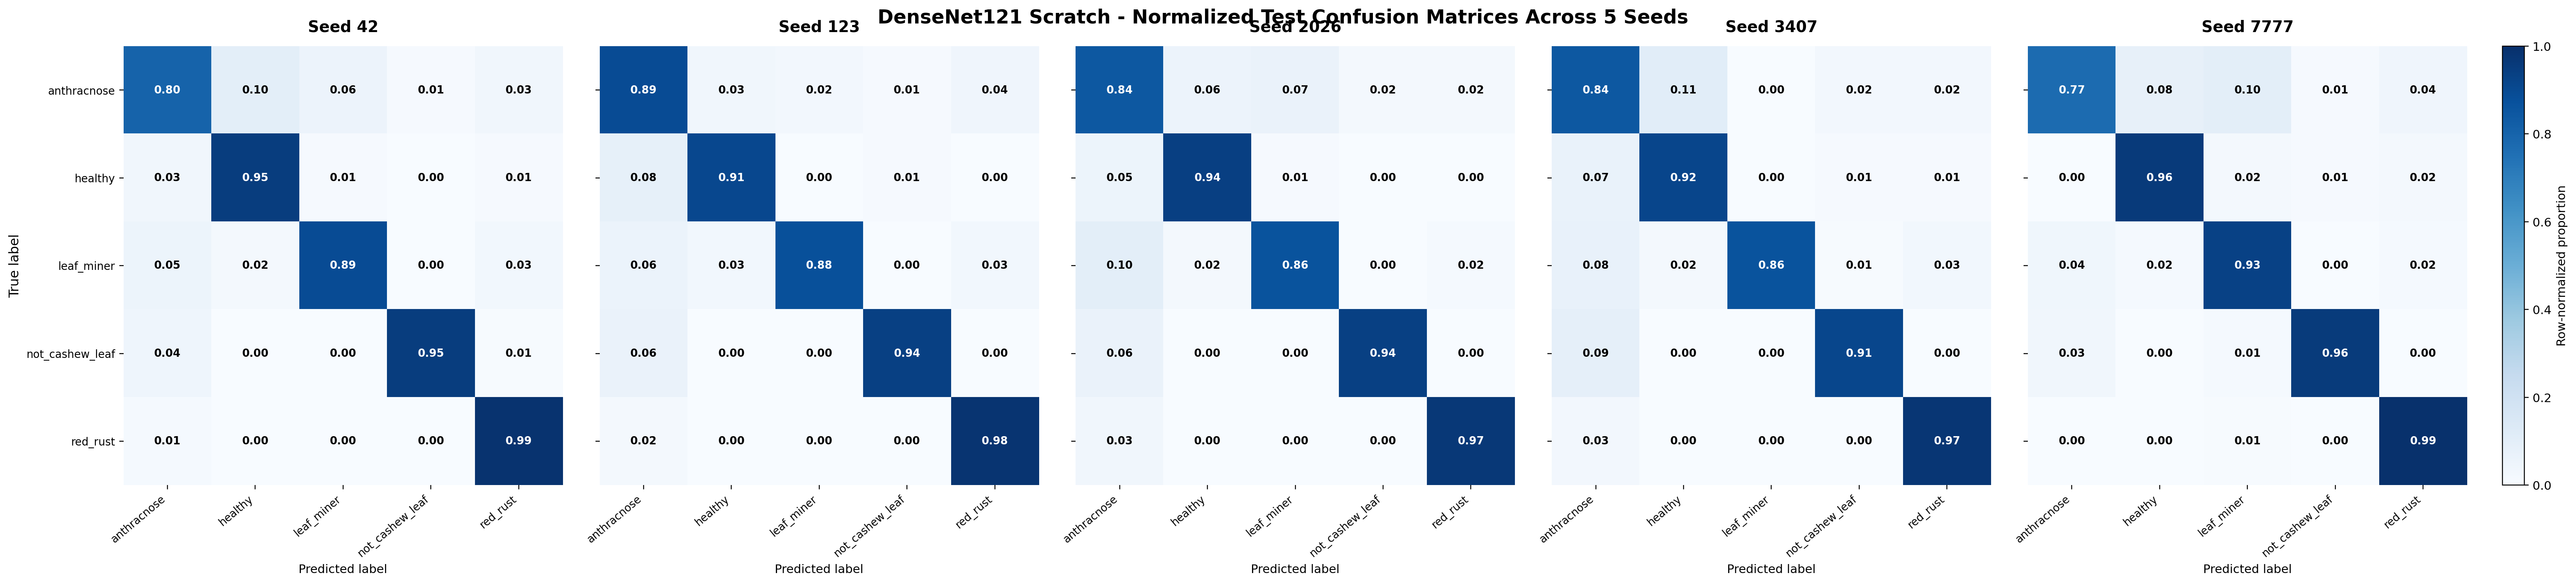

Updated experiment_config.json: final_test_completed = True


In [19]:
# ============================================================
# 17B. PAPER-STYLE TEST CONFUSION MATRIX PANELS
# ============================================================

if not RUN_FINAL_TEST:

    print("Skipped: Final Test chưa chạy.")

else:

    # ========================================================
    # 1. LOAD ALL CONFUSION MATRICES
    # ========================================================

    raw_cms = {}
    normalized_cms = {}

    for seed in SEEDS:

        raw_path = (
            OUT_DIR /
            f"seed_{seed}" /
            "test_metrics" /
            "confusion_matrix.csv"
        )

        normalized_path = (
            OUT_DIR /
            f"seed_{seed}" /
            "test_metrics" /
            "confusion_matrix_normalized.csv"
        )

        raw_cms[seed] = (
            pd.read_csv(
                raw_path,
                index_col=0
            )
            .to_numpy()
        )

        normalized_cms[seed] = (
            pd.read_csv(
                normalized_path,
                index_col=0
            )
            .to_numpy()
        )


    # ========================================================
    # 2. RAW CONFUSION MATRICES - 5 SEEDS SIDE BY SIDE
    # ========================================================

    raw_vmax = max(
        np.max(raw_cms[seed])
        for seed in SEEDS
    )

    fig, axes = plt.subplots(
        1,
        len(SEEDS),
        figsize=(30, 6.5),
        constrained_layout=True
    )

    last_im = None

    for col, seed in enumerate(SEEDS):

        cm = raw_cms[seed]
        ax = axes[col]

        last_im = ax.imshow(
            cm,
            cmap="Blues",
            vmin=0,
            vmax=raw_vmax,
            aspect="equal"
        )

        ax.set_title(
            f"Seed {seed}",
            fontsize=13,
            fontweight="bold",
            pad=12
        )

        ax.set_xticks(
            range(NUM_CLASSES)
        )

        ax.set_yticks(
            range(NUM_CLASSES)
        )

        ax.set_xticklabels(
            CLASS_NAMES,
            rotation=40,
            ha="right",
            fontsize=9
        )

        if col == 0:

            ax.set_yticklabels(
                CLASS_NAMES,
                fontsize=9
            )

            ax.set_ylabel(
                "True label",
                fontsize=11
            )

        else:

            ax.set_yticklabels([])

        ax.set_xlabel(
            "Predicted label",
            fontsize=10
        )

        # ----------------------------------------------------
        # Cell values
        # ----------------------------------------------------

        for i in range(NUM_CLASSES):

            for j in range(NUM_CLASSES):

                value = int(
                    cm[i, j]
                )

                text_color = (
                    "white"
                    if value >= raw_vmax * 0.55
                    else "black"
                )

                ax.text(
                    j,
                    i,
                    f"{value}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color=text_color
                )

        # Remove outer frame
        for spine in ax.spines.values():
            spine.set_visible(False)


    # --------------------------------------------------------
    # Shared colorbar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        last_im,
        ax=axes,
        fraction=0.018,
        pad=0.015
    )

    cbar.set_label(
        "Number of images",
        fontsize=10
    )

    fig.suptitle(
        (
            "DenseNet121 Scratch - "
            "Test Confusion Matrices Across 5 Seeds"
        ),
        fontsize=16,
        fontweight="bold"
    )

    raw_panel = (
        PANEL_DIR /
        "test_confusion_matrices_5seeds_panel.png"
    )

    fig.savefig(
        raw_panel,
        dpi=220,
        bbox_inches="tight"
    )

    plt.close(fig)


    # ========================================================
    # 3. NORMALIZED CONFUSION MATRICES
    # ========================================================

    fig, axes = plt.subplots(
        1,
        len(SEEDS),
        figsize=(30, 6.5),
        constrained_layout=True
    )

    last_im = None

    for col, seed in enumerate(SEEDS):

        cm = normalized_cms[seed]
        ax = axes[col]

        last_im = ax.imshow(
            cm,
            cmap="Blues",
            vmin=0.0,
            vmax=1.0,
            aspect="equal"
        )

        ax.set_title(
            f"Seed {seed}",
            fontsize=13,
            fontweight="bold",
            pad=12
        )

        ax.set_xticks(
            range(NUM_CLASSES)
        )

        ax.set_yticks(
            range(NUM_CLASSES)
        )

        ax.set_xticklabels(
            CLASS_NAMES,
            rotation=40,
            ha="right",
            fontsize=9
        )

        if col == 0:

            ax.set_yticklabels(
                CLASS_NAMES,
                fontsize=9
            )

            ax.set_ylabel(
                "True label",
                fontsize=11
            )

        else:

            ax.set_yticklabels([])

        ax.set_xlabel(
            "Predicted label",
            fontsize=10
        )

        # ----------------------------------------------------
        # Cell values
        # ----------------------------------------------------

        for i in range(NUM_CLASSES):

            for j in range(NUM_CLASSES):

                value = float(
                    cm[i, j]
                )

                text_color = (
                    "white"
                    if value >= 0.55
                    else "black"
                )

                ax.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color=text_color
                )

        # Remove outer frame
        for spine in ax.spines.values():
            spine.set_visible(False)


    # --------------------------------------------------------
    # Shared colorbar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        last_im,
        ax=axes,
        fraction=0.018,
        pad=0.015
    )

    cbar.set_label(
        "Row-normalized proportion",
        fontsize=10
    )

    fig.suptitle(
        (
            "DenseNet121 Scratch - "
            "Normalized Test Confusion Matrices Across 5 Seeds"
        ),
        fontsize=16,
        fontweight="bold"
    )

    normalized_panel = (
        PANEL_DIR /
        "test_confusion_matrices_normalized_5seeds_panel.png"
    )

    fig.savefig(
        normalized_panel,
        dpi=220,
        bbox_inches="tight"
    )

    plt.close(fig)


    # ========================================================
    # 4. OUTPUT
    # ========================================================

    print(
        "Created:",
        raw_panel
    )

    print(
        "Created:",
        normalized_panel
    )

    display(
        Image.open(
            normalized_panel
        )
    )


    # ========================================================
    # 5. UPDATE EXPERIMENT METADATA
    # ========================================================

    _cfg = json.loads(
        config_path.read_text(
            encoding="utf-8"
        )
    )

    _cfg.setdefault(
        "test_protocol",
        {}
    )

    _cfg[
        "test_protocol"
    ][
        "run_final_test"
    ] = True

    _cfg[
        "test_protocol"
    ][
        "final_test_completed"
    ] = True

    config_path.write_text(
        json.dumps(
            _cfg,
            indent=2,
            ensure_ascii=False
        ),
        encoding="utf-8"
    )

    print(
        "Updated experiment_config.json: "
        "final_test_completed = True"
    )


# Deployment package for later YOLO integration

Để FULL archive có thể dùng lại sau này, notebook export một model deployment **chỉ dựa trên Validation**.

Seed deployment được chọn bằng:

```text
highest Validation Macro-F1
→ tie-break: lower Validation Loss
```

Test không tham gia lựa chọn seed deployment.

Archive sẽ có:

```text
model_package/
├── deployment_model.keras
├── densenet121_feature_extractor.keras
├── densenet121_embedding_model.keras
├── deployment_metadata.json
└── label_map.json
```

- `deployment_model.keras`: dùng trực tiếp cho pipeline `YOLO crop → DenseNet classifier`.
- `densenet121_feature_extractor.keras`: feature map trước Global Average Pooling.
- `densenet121_embedding_model.keras`: vector embedding sau Global Average Pooling, hữu ích nếu sau này cần feature fusion.


In [20]:

# ============================================================
# 18. EXPORT DEPLOYMENT MODEL PACKAGE - VALIDATION ONLY
# ============================================================

if "validation_results_df" not in globals():
    validation_results_df = pd.read_csv(
        AGGREGATE_DIR / "validation_results_5seeds.csv"
    )

ranked = validation_results_df.sort_values(
    ["val_macro_f1", "val_loss"],
    ascending=[False, True]
).reset_index(drop=True)

deployment_seed = int(ranked.loc[0, "seed"])
DEMO_SEED = deployment_seed

print("Deployment seed selected by Validation only:", deployment_seed)

deployment_weights_path = (
    OUT_DIR / f"seed_{deployment_seed}" / "checkpoints" /
    f"DENSENET121_SCRATCH_seed_{deployment_seed}_best.weights.h5"
)

if not deployment_weights_path.exists():
    raise FileNotFoundError(deployment_weights_path)

tf.keras.backend.clear_session()
gc.collect()

with strategy.scope():
    deployment_model = build_densenet121_model(deployment_seed)
    deployment_model.load_weights(deployment_weights_path)

# Fresh uncompiled model -> portable .keras without relying on old optimizer state.
deployment_model_path = MODEL_PACKAGE_DIR / "deployment_model.keras"
deployment_model.save(deployment_model_path)

# ------------------------------------------------------------
# Standalone DenseNet feature extractor for downstream YOLO.
# Rebuild inference-only preprocessing + backbone and copy the
# trained DenseNet121 weights from the deployment classifier.
# ------------------------------------------------------------

trained_backbone = deployment_model.get_layer("densenet121")

feature_inputs = keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="image"
)

feature_x = layers.Rescaling(
    1.0 / 255.0,
    name="rescale_0_1"
)(feature_inputs)

feature_backbone = tf.keras.applications.DenseNet121(
    include_top=False,
    weights=None,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
feature_backbone.set_weights(
    trained_backbone.get_weights()
)

feature_outputs = feature_backbone(
    feature_x,
    training=False
)

feature_extractor = keras.Model(
    inputs=feature_inputs,
    outputs=feature_outputs,
    name="DenseNet121_feature_extractor"
)
feature_extractor_path = MODEL_PACKAGE_DIR / "densenet121_feature_extractor.keras"
feature_extractor.save(feature_extractor_path)

embedding_outputs = layers.GlobalAveragePooling2D(
    name="embedding_global_average_pooling"
)(feature_outputs)

embedding_model = keras.Model(
    inputs=feature_inputs,
    outputs=embedding_outputs,
    name="DenseNet121_embedding_model"
)
embedding_model_path = MODEL_PACKAGE_DIR / "densenet121_embedding_model.keras"
embedding_model.save(embedding_model_path)

label_map = {str(i): name for i, name in enumerate(CLASS_NAMES)}
(MODEL_PACKAGE_DIR / "label_map.json").write_text(
    json.dumps(label_map, indent=2), encoding="utf-8"
)

deployment_metadata = {
    "experiment_id": EXPERIMENT_ID,
    "model": MODEL_NAME,
    "training_mode": TRAINING_MODE,
    "deployment_seed": deployment_seed,
    "selection_source": "validation only",
    "selection_metric": "val_macro_f1",
    "tie_break": "lower val_loss",
    "test_used_for_selection": False,
    "input_size": [IMG_SIZE, IMG_SIZE, 3],
    "class_names": CLASS_NAMES,
    "contains_rescaling_layer": True,
    "external_divide_by_255": False,
    "deployment_model": "deployment_model.keras",
    "feature_extractor": "densenet121_feature_extractor.keras",
    "embedding_model": "densenet121_embedding_model.keras",
    "embedding_dimension": 1024,
    "intended_downstream_use": "YOLO crop classification or feature fusion",
    "source_weights": str(deployment_weights_path),
}
(MODEL_PACKAGE_DIR / "deployment_metadata.json").write_text(
    json.dumps(deployment_metadata, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("Saved deployment model :", deployment_model_path)
print("Saved feature extractor:", feature_extractor_path)
print("Saved embedding model  :", embedding_model_path)


Deployment seed selected by Validation only: 7777
Global seed set to: 7777
Saved deployment model : /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/model_package/deployment_model.keras
Saved feature extractor: /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/model_package/densenet121_feature_extractor.keras
Saved embedding model  : /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003/model_package/densenet121_embedding_model.keras


In [21]:

# ============================================================
# 19. EXPORT REUSABLE CODE FOR FUTURE YOLO / CONTINUE TRAINING
# ============================================================

model_builder_code = r"""
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def build_data_augmentation(seed):
    return keras.Sequential([
        layers.RandomFlip("horizontal", seed=seed + 1),
        layers.RandomRotation(0.04, seed=seed + 2),
        layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            seed=seed + 3,
        ),
        layers.RandomTranslation(0.03, 0.03, seed=seed + 4),
        layers.RandomContrast(0.08, seed=seed + 5),
    ], name=f"data_augmentation_seed_{seed}")


def build_densenet121_model(seed, img_size=224, num_classes=5, head_units=512, head_dropout=0.40):
    keras.utils.set_random_seed(seed)
    inputs = keras.Input(shape=(img_size, img_size, 3), name="image")
    x = build_data_augmentation(seed)(inputs)
    x = layers.Rescaling(1.0 / 255.0, name="rescale_0_1")(x)
    backbone = tf.keras.applications.DenseNet121(
        include_top=False,
        weights=None,
        input_shape=(img_size, img_size, 3),
    )
    backbone.trainable = True
    x = backbone(x)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dense(head_units, activation="relu", name="classifier_dense")(x)
    x = layers.BatchNormalization(name="classifier_bn")(x)
    x = layers.Dropout(head_dropout, seed=seed + 6, name="classifier_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)
    return keras.Model(inputs, outputs, name=f"DenseNet121_Scratch_seed_{seed}")
"""

(CODE_PACKAGE_DIR / "densenet121_model_builder.py").write_text(
    model_builder_code, encoding="utf-8"
)

yolo_adapter_code = r"""
# YOLO detection -> DenseNet121 crop classifier example.
# deployment_model.keras already contains Rescaling(1/255),
# so do NOT divide the crop by 255 outside the model.

from pathlib import Path
import json
import numpy as np
from PIL import Image
from tensorflow import keras

MODEL_DIR = Path("model_package")
classifier = keras.models.load_model(MODEL_DIR / "deployment_model.keras", compile=False)
label_map = json.loads((MODEL_DIR / "label_map.json").read_text())


def classify_crop(crop, img_size=224):
    if isinstance(crop, np.ndarray):
        crop = Image.fromarray(crop.astype(np.uint8))
    crop = crop.convert("RGB").resize((img_size, img_size))
    x = np.asarray(crop, dtype=np.float32)[None, ...]
    probs = classifier.predict(x, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    return {
        "class_id": pred_id,
        "class_name": label_map[str(pred_id)],
        "confidence": float(probs[pred_id]),
        "probabilities": probs.tolist(),
    }
"""
(CODE_PACKAGE_DIR / "yolo_classifier_adapter.py").write_text(
    yolo_adapter_code, encoding="utf-8"
)

continue_training_code = r"""
from tensorflow import keras

model = keras.models.load_model(
    "model_package/deployment_model.keras",
    compile=False,
)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

# Continue with your train_ds / val_ds:
# model.fit(train_ds, validation_data=val_ds, ...)
"""
(CODE_PACKAGE_DIR / "continue_training_example.py").write_text(
    continue_training_code, encoding="utf-8"
)

print("Reusable code package:")
for p in sorted(CODE_PACKAGE_DIR.iterdir()):
    print("-", p.name)


Reusable code package:
- continue_training_example.py
- densenet121_model_builder.py
- yolo_classifier_adapter.py



# Manual image inference

Manual demo dùng `deployment_model.keras`, tức seed được chọn bằng **Validation only**.

Model đã chứa `Rescaling(1/255)`, vì vậy không chia ảnh cho 255 ở ngoài model.


In [22]:
# ============================================================
# 20. MANUAL UPLOAD INFERENCE
#     SAFE FOR SINGLE IMAGE + MIRRORED STRATEGY
# ============================================================

# ------------------------------------------------------------
# Load deployment model if needed
# ------------------------------------------------------------

if "deployment_model" not in globals():

    deployment_model = keras.models.load_model(
        MODEL_PACKAGE_DIR /
        "deployment_model.keras",
        compile=False
    )

print(
    "Deployment model ready."
)

print(
    "Number of replicas:",
    strategy.num_replicas_in_sync
)


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_uploaded_image(
    model,
    image_bytes,
    filename
):

    # --------------------------------------------------------
    # 1. Read uploaded image
    # --------------------------------------------------------

    img = Image.open(
        io.BytesIO(
            image_bytes
        )
    ).convert(
        "RGB"
    )

    # --------------------------------------------------------
    # 2. Resize
    # --------------------------------------------------------

    img_resized = img.resize(
        (
            IMG_SIZE,
            IMG_SIZE
        )
    )

    img_array = np.asarray(
        img_resized,
        dtype=np.float32
    )

    # Original single sample
    single_batch = np.expand_dims(
        img_array,
        axis=0
    )

    # --------------------------------------------------------
    # 3. IMPORTANT:
    # MirroredStrategy cannot safely predict batch=1
    # when using multiple GPUs.
    #
    # Repeat the SAME image so each GPU receives >= 1 sample.
    # --------------------------------------------------------

    num_replicas = max(
        1,
        int(
            strategy.num_replicas_in_sync
        )
    )

    inference_batch = np.repeat(
        single_batch,
        repeats=num_replicas,
        axis=0
    )

    print(
        "Input batch shape:",
        inference_batch.shape
    )

    # Example T4 x2:
    # (2, 224, 224, 3)
    #
    # GPU 0 -> 1 image
    # GPU 1 -> 1 image

    # --------------------------------------------------------
    # 4. Predict
    # --------------------------------------------------------

    all_probs = model.predict(
        inference_batch,
        verbose=0
    )

    # Every repeated sample is identical.
    # Only use prediction of the first one.
    probs = all_probs[0]

    # --------------------------------------------------------
    # 5. Decode prediction
    # --------------------------------------------------------

    pred_idx = int(
        np.argmax(
            probs
        )
    )

    confidence = float(
        probs[
            pred_idx
        ]
    )

    # --------------------------------------------------------
    # 6. Result table
    # --------------------------------------------------------

    result_df = pd.DataFrame({
        "Class": CLASS_NAMES,
        "Probability": probs,
        "Probability (%)": (
            probs * 100
        ),
    }).sort_values(
        "Probability",
        ascending=False
    ).reset_index(
        drop=True
    )

    # --------------------------------------------------------
    # 7. Display result
    # --------------------------------------------------------

    print(
        "=" * 65
    )

    print(
        "Image           :",
        filename
    )

    print(
        "Prediction      :",
        CLASS_NAMES[
            pred_idx
        ]
    )

    print(
        f"Confidence      : "
        f"{confidence * 100:.2f}%"
    )

    print(
        "Deployment seed :",
        DEMO_SEED
    )

    print(
        "GPU replicas    :",
        num_replicas
    )

    print(
        "=" * 65
    )

    display(
        result_df
    )

    # --------------------------------------------------------
    # 8. Show image
    # --------------------------------------------------------

    plt.figure(
        figsize=(7, 7)
    )

    plt.imshow(
        img
    )

    plt.title(
        (
            f"Prediction: "
            f"{CLASS_NAMES[pred_idx]}\n"
            f"Confidence: "
            f"{confidence * 100:.2f}%"
        )
    )

    plt.axis(
        "off"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# FILE UPLOAD WIDGET
# ============================================================

uploader = widgets.FileUpload(
    accept=(
        ".jpg,.jpeg,.png,.webp"
    ),
    multiple=False,
    description="Upload Image"
)

predict_button = widgets.Button(
    description="Predict",
    button_style="success",
    icon="check"
)

output = widgets.Output()

display(
    uploader
)

display(
    predict_button
)

display(
    output
)


# ============================================================
# READ UPLOADED FILE
# Compatible with ipywidgets 7 and 8
# ============================================================

def get_uploaded_file(
    upload_widget
):

    value = (
        upload_widget.value
    )

    if not value:
        return None, None

    # --------------------------------------------------------
    # ipywidgets 8
    # --------------------------------------------------------

    if isinstance(
        value,
        (tuple, list)
    ):

        uploaded_file = (
            value[0]
        )

        filename = (
            uploaded_file[
                "name"
            ]
        )

        content = (
            uploaded_file[
                "content"
            ]
        )

        if hasattr(
            content,
            "tobytes"
        ):
            content = (
                content.tobytes()
            )

        return (
            filename,
            content
        )

    # --------------------------------------------------------
    # ipywidgets 7
    # --------------------------------------------------------

    if isinstance(
        value,
        dict
    ):

        filename = list(
            value.keys()
        )[0]

        uploaded_file = (
            value[
                filename
            ]
        )

        content = (
            uploaded_file[
                "content"
            ]
        )

        if hasattr(
            content,
            "tobytes"
        ):
            content = (
                content.tobytes()
            )

        return (
            filename,
            content
        )

    return None, None


# ============================================================
# BUTTON CALLBACK
# ============================================================

def on_predict_clicked(_):

    with output:

        output.clear_output()

        filename, image_bytes = (
            get_uploaded_file(
                uploader
            )
        )

        if image_bytes is None:

            print(
                "Vui lòng upload ảnh trước."
            )

            return

        try:

            predict_uploaded_image(
                deployment_model,
                image_bytes,
                filename
            )

        except Exception as e:

            print(
                "Prediction error:"
            )

            print(
                type(e).__name__,
                ":",
                e
            )


predict_button.on_click(
    on_predict_clicked
)

print(
    "Upload một ảnh rồi bấm Predict."
)

Deployment model ready.
Number of replicas: 2


FileUpload(value=(), accept='.jpg,.jpeg,.png,.webp', description='Upload Image')

Button(button_style='success', description='Predict', icon='check', style=ButtonStyle())

Output()

Upload một ảnh rồi bấm Predict.


In [23]:

# ============================================================
# 21. ENVIRONMENT + README + ARCHIVE FORMAT
# ============================================================

environment_info = {
    "created_at": datetime.now().isoformat(),
    "python": sys.version,
    "tensorflow": tf.__version__,
    "keras": keras.__version__ if hasattr(keras, "__version__") else "tf.keras",
    "platform": platform.platform(),
    "gpu_count": len(gpus),
    "gpu_devices": [str(g) for g in gpus],
    "strategy": strategy.__class__.__name__,
    "replicas": strategy.num_replicas_in_sync,
}
(ENV_DIR / "environment.json").write_text(
    json.dumps(environment_info, indent=2), encoding="utf-8"
)

requirements_text = f"""tensorflow=={tf.__version__}
numpy=={np.__version__}
pandas=={pd.__version__}
Pillow
scikit-learn
matplotlib
"""
(ENV_DIR / "requirements.txt").write_text(requirements_text, encoding="utf-8")

archive_format = f"""# KLCN Classification Training Archive Format v1

- Experiment: {EXPERIMENT_ID}
- Dataset: {DATASET_VERSION}
- Model: {MODEL_NAME}
- Seeds: {SEEDS}
- Google Drive target: {DRIVE_TARGET_URL}

## Required archive content
- all five best checkpoints;
- model_package for deployment / YOLO integration;
- code package for rebuilding and continued training;
- histories, metrics, reports, predictions and error cases;
- paper-style seed comparison panels;
- environment and requirements;
- README, manifest and SHA256 checksums.

## Figure rule
Any figure whose purpose is to compare seeds must present all 5 seeds side-by-side in one panel.

## Scientific rule
Same split + same hyperparameters for all seeds. Test is locked for tuning. Deployment seed is selected from Validation only.
"""
(OUT_DIR / "ARCHIVE_FORMAT.md").write_text(archive_format, encoding="utf-8")

# README
validation_summary_path = AGGREGATE_DIR / "validation_mean_std_summary.csv"
validation_summary = pd.read_csv(validation_summary_path) if validation_summary_path.exists() else None

lines = [
    f"# {EXPERIMENT_ID}", "",
    f"**Model:** {MODEL_NAME} from scratch  ",
    f"**Dataset:** {DATASET_VERSION}  ",
    f"**Seeds:** `{SEEDS}`", "",
    "## Dataset", "",
    "| Class | Train | Val | Test | Total |",
    "|---|---:|---:|---:|---:|",
]
for cls in CLASS_NAMES:
    r = EXPECTED_COUNTS[cls]
    lines.append(f"| {cls} | {r['train']} | {r['val']} | {r['test']} | {r['total']} |")
lines += [
    f"| **TOTAL** | **{EXPECTED_TOTALS['train']}** | **{EXPECTED_TOTALS['val']}** | **{EXPECTED_TOTALS['test']}** | **{EXPECTED_TOTALS['total']}** |",
    "",
    "## Configuration", "",
    f"- Input: `{IMG_SIZE}×{IMG_SIZE}`",
    f"- Batch size: `{BATCH_SIZE}`",
    f"- Initial LR: `{INITIAL_LR}`",
    f"- Max epochs: `{MAX_EPOCHS}`",
    "- Optimizer: Adam",
    "- Checkpoint: minimum val_loss",
    "- Backbone call: `x = backbone(x)`",
    "",
    "## Training curves — 5 seeds side-by-side", "",
    "![Training curves](./figures/panels/training_curves_5seeds_panel.png)", "",
    "## Validation confusion matrices — 5 seeds side-by-side", "",
    "![Validation CM](./figures/panels/validation_confusion_matrices_5seeds_panel.png)", "",
]

if validation_summary is not None:
    lines += ["## Validation Mean ± Std", "", "| Metric | Result |", "|---|---:|"]
    for _, r in validation_summary.iterrows():
        lines.append(f"| {r['metric']} | **{r['report']}** |")
    lines.append("")

if RUN_FINAL_TEST and (AGGREGATE_DIR / "thesis_test_mean_std_summary.csv").exists():
    thesis = pd.read_csv(AGGREGATE_DIR / "thesis_test_mean_std_summary.csv")
    lines += ["## Final Test Mean ± Std", "", "| Metric | Result |", "|---|---:|"]
    for _, r in thesis.iterrows():
        lines.append(f"| {r['Metric']} | **{r['Report']}** |")
    lines += [
        "",
        "## Test confusion matrices — 5 seeds side-by-side", "",
        "![Test CM](./figures/panels/test_confusion_matrices_5seeds_panel.png)", "",
        "## Normalized Test confusion matrices — 5 seeds side-by-side", "",
        "![Normalized Test CM](./figures/panels/test_confusion_matrices_normalized_5seeds_panel.png)", "",
    ]

if (MODEL_PACKAGE_DIR / "deployment_metadata.json").exists():
    meta = json.loads((MODEL_PACKAGE_DIR / "deployment_metadata.json").read_text())
    lines += [
        "## Deployment / YOLO integration", "",
        f"Deployment seed selected from Validation only: **{meta['deployment_seed']}**.", "",
        "Reusable files:",
        "- `model_package/deployment_model.keras`",
        "- `model_package/densenet121_feature_extractor.keras`",
        "- `model_package/densenet121_embedding_model.keras`",
        "- `code/yolo_classifier_adapter.py`",
        "- `code/continue_training_example.py`",
        "",
    ]

lines += [
    "## Google Drive archive", "",
    f"Full ZIP destination: {DRIVE_TARGET_URL}", "",
    f"Archive name: `{EXPERIMENT_ID}_FULL.zip`", "",
    "## Scientific rules", "",
    "- Same Train/Val/Test split for all seeds.",
    "- Same hyperparameters for all seeds.",
    "- Test is not used for tuning.",
    "- Deployment seed is selected from Validation only.",
    "- Mean ± sample standard deviation (`ddof=1`).",
]

(OUT_DIR / "README.md").write_text("\n".join(lines), encoding="utf-8")
print("Saved README and environment metadata.")


Saved README and environment metadata.


In [24]:

# ============================================================
# 22. MANIFEST + SHA256 + FULL/ANALYSIS ZIP
# ============================================================

# ------------------------------------------------------------
# File manifest + checksums
# ------------------------------------------------------------
manifest_rows = []
checksum_lines = []

for file_path in sorted(OUT_DIR.rglob("*")):
    if not file_path.is_file():
        continue
    relative = file_path.relative_to(OUT_DIR)
    if relative.name in {"FILE_MANIFEST.csv", "CHECKSUMS.sha256"}:
        continue

    sha = hashlib.sha256()
    with file_path.open("rb") as f:
        while True:
            chunk = f.read(1024 * 1024)
            if not chunk:
                break
            sha.update(chunk)
    digest = sha.hexdigest()
    manifest_rows.append({
        "path": str(relative),
        "size_bytes": int(file_path.stat().st_size),
        "size_mb": float(file_path.stat().st_size / (1024 ** 2)),
        "sha256": digest,
    })
    checksum_lines.append(f"{digest}  {relative}")

pd.DataFrame(manifest_rows).to_csv(OUT_DIR / "FILE_MANIFEST.csv", index=False)
(OUT_DIR / "CHECKSUMS.sha256").write_text("\n".join(checksum_lines), encoding="utf-8")

# ------------------------------------------------------------
# Full archive: contains models/checkpoints for future reuse.
# Dataset images are NOT copied into the archive.
# ------------------------------------------------------------
FULL_ZIP = Path("/kaggle/working") / f"{EXPERIMENT_ID}_FULL.zip"
ANALYSIS_ZIP = Path("/kaggle/working") / f"{EXPERIMENT_ID}_ANALYSIS.zip"

with zipfile.ZipFile(FULL_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file_path in OUT_DIR.rglob("*"):
        if file_path.is_file():
            relative = file_path.relative_to(OUT_DIR)
            zipf.write(file_path, arcname=Path(EXPERIMENT_ID) / relative)

# Lightweight archive for ChatGPT / analysis.
allowed = {".csv", ".json", ".md", ".png", ".txt", ".sha256"}
skip_folders = {"checkpoints", "model_package"}

with zipfile.ZipFile(ANALYSIS_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file_path in OUT_DIR.rglob("*"):
        if not file_path.is_file():
            continue
        relative = file_path.relative_to(OUT_DIR)
        if any(part in skip_folders for part in relative.parts):
            continue
        if file_path.suffix.lower() not in allowed:
            continue
        zipf.write(file_path, arcname=Path(EXPERIMENT_ID) / relative)

print("=" * 70)
print("ARCHIVES READY")
print("=" * 70)
print("FULL ZIP     :", FULL_ZIP)
print(f"FULL SIZE    : {FULL_ZIP.stat().st_size / (1024 ** 2):.2f} MB")
print("ANALYSIS ZIP :", ANALYSIS_ZIP)
print(f"ANALYSIS SIZE: {ANALYSIS_ZIP.stat().st_size / (1024 ** 2):.2f} MB")
print()
print("GOOGLE DRIVE TARGET:")
print(DRIVE_TARGET_URL)
print()
print("Upload FULL ZIP to the Drive target. Keep ANALYSIS ZIP for quick review.")


ARCHIVES READY
FULL ZIP     : /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003_FULL.zip
FULL SIZE    : 474.03 MB
ANALYSIS ZIP : /kaggle/working/EXP-DENSENET121-SCRATCH-5SEEDS-003_ANALYSIS.zip
ANALYSIS SIZE: 3.23 MB

GOOGLE DRIVE TARGET:
https://drive.google.com/drive/folders/1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing

Upload FULL ZIP to the Drive target. Keep ANALYSIS ZIP for quick review.



# Final checklist — common format from now on

## Before training
- [ ] Restart Session → Run All.
- [ ] Dataset audit = 7,213 valid / 0 bad / 0 unknown.
- [ ] DenseNet121 `weights=None`.
- [ ] `x = backbone(x)` and no forced `training=True`.
- [ ] Fixed seeds `[42, 123, 2026, 3407, 7777]`.

## Results
- [ ] All 5 best checkpoints exist.
- [ ] Validation Mean ± Std exists.
- [ ] Final Test only after configuration lock.
- [ ] Test Mean ± Std and per-class summary exist.

## Paper-style figures
- [ ] `training_curves_5seeds_panel.png` — 2×5 panel.
- [ ] `validation_confusion_matrices_5seeds_panel.png` — 1×5 panel.
- [ ] `test_confusion_matrices_5seeds_panel.png` — 1×5 panel.
- [ ] `test_confusion_matrices_normalized_5seeds_panel.png` — 1×5 panel.

## Future YOLO reuse
- [ ] All five best `.weights.h5` included in FULL ZIP.
- [ ] `deployment_model.keras`.
- [ ] `densenet121_feature_extractor.keras`.
- [ ] `densenet121_embedding_model.keras`.
- [ ] `label_map.json` + deployment metadata.
- [ ] `yolo_classifier_adapter.py`.
- [ ] `continue_training_example.py`.

## Reproducibility
- [ ] `experiment_config.json`.
- [ ] `dataset_manifest.csv`.
- [ ] histories / metrics / predictions / error cases.
- [ ] environment + requirements.
- [ ] `FILE_MANIFEST.csv`.
- [ ] `CHECKSUMS.sha256`.
- [ ] README.

## Archives
- [ ] `EXP-DENSENET121-SCRATCH-5SEEDS-002_FULL.zip`.
- [ ] `EXP-DENSENET121-SCRATCH-5SEEDS-002_ANALYSIS.zip`.

## Google Drive
Full archive destination:

```text
https://drive.google.com/drive/folders/1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing
```
